# 00 · Extracción — IVR Alkosto (datos junio 2026)

Consulta directamente `vw_emt_gc_detalle_ivr` y aplana
`atributos_custom` en columnas `customN`.

**Salida:** `data/00_raw/df_raw_<fecha_inicio>_<fecha_fin>.parquet` — insumo del
Notebook 2 (`01_reconstruccion_traza.ipynb`).

**Requisitos:**
- Archivo `.env` en la raíz del proyecto (mismo nivel que este notebook o un nivel
  arriba) con las credenciales de conexión.
- `pip install python-dotenv psycopg2-binary pandas pyarrow`

In [1]:
import os
import warnings
from pathlib import Path

import pandas as pd
import psycopg2
from dotenv import load_dotenv

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)

### Parámetros del análisis

Ajusta aquí el periodo y la división antes de correr el resto del notebook. Todo lo
que sigue depende de estos valores — no hay rutas ni fechas quemadas más abajo.

In [2]:
# --- Parámetros editables ---
FECHA_INICIO = "2026-06-01"
FECHA_FIN = "2026-06-30"

DIVISIONES = ["Alkosto", "Home,Alkosto", "Alkosto,Home"]

ORGANIZACION = "emtelcosas"

# Carpeta raíz de datos del proyecto (ajusta si tu estructura es distinta)
DATA_DIR = Path("../data") if Path("../data").exists() else Path("data")
RAW_DIR = DATA_DIR / "00_raw"
RAW_DIR.mkdir(parents=True, exist_ok=True)

OUTPUT_PATH = RAW_DIR / f"df_raw_{FECHA_INICIO}_{FECHA_FIN}.parquet"
OUTPUT_PATH_FLAT = RAW_DIR / f"df_flat_{FECHA_INICIO}_{FECHA_FIN}.parquet"

print(f"Salida esperada: {OUTPUT_PATH}")
print(f"Salida esperada: {OUTPUT_PATH_FLAT}")

Salida esperada: data\00_raw\df_raw_2026-06-01_2026-06-30.parquet
Salida esperada: data\00_raw\df_flat_2026-06-01_2026-06-30.parquet


### Conexión

In [3]:
load_dotenv()  # busca un archivo .env en el directorio actual o en los padres

DB_USER = os.getenv("IVR_DB_USER")
DB_PASSWORD = os.getenv("IVR_DB_PASSWORD")
DB_HOST = os.getenv("IVR_DB_HOST")
DB_PORT = int(os.getenv("IVR_DB_PORT", "5432"))
DB_NAME = os.getenv("IVR_DB_NAME")

faltantes = [
    nombre
    for nombre, valor in {
        "IVR_DB_USER": DB_USER,
        "IVR_DB_PASSWORD": DB_PASSWORD,
        "IVR_DB_HOST": DB_HOST,
        "IVR_DB_NAME": DB_NAME,
    }.items()
    if not valor
]
if faltantes:
    raise RuntimeError(
        f"Faltan variables de entorno en tu .env: {faltantes}. "
        "Revisa .env para ver los nombres esperados."
    )

In [4]:
con = psycopg2.connect(
    user=DB_USER,
    password=DB_PASSWORD,
    host=DB_HOST,
    port=DB_PORT,
    dbname=DB_NAME,
)

### Consulta parametrizada

Usa placeholders `%s` (psycopg2 los sustituye de forma segura) en vez de f-strings,
para no repetir el patrón de fechas/organización.

In [5]:
sql_query = """
SELECT *
FROM public.vw_emt_gc_detalle_ivr
WHERE organizacion = %(organizacion)s
  AND division = ANY(%(divisiones)s)
  AND fecha_inicio >= %(fecha_inicio)s
  AND fecha_inicio <= %(fecha_fin)s
ORDER BY fecha_inicio;
"""

params = {
    "organizacion": ORGANIZACION,
    "divisiones": DIVISIONES,
    "fecha_inicio": FECHA_INICIO,
    "fecha_fin": FECHA_FIN,
}

df = pd.read_sql_query(sql_query, con, params=params)
con.close()
print(df.shape)
df.head(3)

(105499, 23)


,organizacion,id_conversacion,ani,dnis,division,nombre_ivr,fecha_hora_ingreso,fecha_hora_fin,duracion_ivr,duracion_navegacion,duracion_transaccional,duracion_paso_ce,duracion_desborde,traza_opciones,ultima_opcion,tipo_ult_opcion,paso_ce,tipo_desconexion,id_campana,atributos_custom,custom_50,fecha_inicio,fecha_fin
0,emtelcosas,891f883b-e8c0-4a43-91a8-00f93459a745,+573212202672,+576014073033,Alkosto,"ALK_IVR_PRINCIPAL,Default In-Queue Flow Alkost...",2026-06-01 18:51:32.530,2026-06-01 19:03:54.720,185663,185095.0,1496.0,284.0,0.0,|0;Inicio IVR ;0|3;Habeas data positivo;48030|...,1003;Finalización por fin de flujo;31,None,SI,System,None,{'custom2': '|2;Numero documento ingresado;102...,None,2026-06-01,2026-06-01
1,emtelcosas,87da4cf9-0f24-4bfa-ac8d-89fb352833e8,680f7a988560a0625a90572d+emtelcosas.orgspan.co...,+573014211759,Alkosto,ALK_IVR_ENCUESTA_SAC,2026-06-01 11:14:39.923,2026-06-01 11:17:15.120,80,NaN,NaN,NaN,NaN,NaN,NaN,None,SI,External,None,{'custom30': ''},None,2026-06-01,2026-06-01
2,emtelcosas,0db1a400-045e-486b-812a-124eacf99f90,+573187789584,+576014073033,Alkosto,"ALK_IVR_PRINCIPAL,Default In-Queue Flow Alkosto",2026-06-01 16:35:06.287,2026-06-01 17:06:25.677,42416,41932.0,1325.0,242.0,0.0,|0;Inicio IVR ;0|17;Menu principal;14164|161;E...,205;Paso agente despachos;157,None,SI,External,None,{'custom2': '|2;Numero documento ingresado;721...,None,2026-06-01,2026-06-01


### Chequeos rápidos de sanidad

Antes de aplanar `atributos_custom`, valida que la extracción trajo lo esperado:
que no venga vacía, que las fechas caigan dentro del rango pedido y que
`id_conversacion` no tenga duplicados exactos.

In [6]:
assert len(df) > 0, "La consulta no trajo filas — revisa parámetros de fecha/división."

print("Filas:", len(df))
print("id_conversacion únicos:", df["id_conversacion"].nunique())
print("Duplicados exactos de id_conversacion:", df["id_conversacion"].duplicated().sum())
print("Rango fecha_inicio:", df["fecha_inicio"].min(), "→", df["fecha_inicio"].max())
print("Divisiones encontradas:", df["division"].unique())
print("\nNulos en traza_opciones:", df["traza_opciones"].isna().sum())

Filas: 105499
id_conversacion únicos: 105499
Duplicados exactos de id_conversacion: 0
Rango fecha_inicio: 2026-06-01 → 2026-06-30
Divisiones encontradas: <ArrowStringArray>
['Alkosto']
Length: 1, dtype: str

Nulos en traza_opciones: 8348


### Aplanado de `atributos_custom`

Cada fila trae un dict con claves `customN`, cada una con un único paso `codigo;texto;tiempo`. Los separamos en
columnas propias para poder reconstruir la traza completa en el Notebook 2.

In [7]:
df_flat = df.join(df["atributos_custom"].apply(pd.Series))

columnas_custom = [c for c in df_flat.columns if c.startswith("custom")]
print(df_flat.shape)
print(f"Columnas custom encontradas ({len(columnas_custom)}):", sorted(columnas_custom))
df_flat[["id_conversacion", "traza_opciones"] + columnas_custom].head(3)

(105499, 42)
Columnas custom encontradas (20): ['custom11', 'custom15', 'custom16', 'custom2', 'custom21', 'custom22', 'custom24', 'custom25', 'custom26', 'custom28', 'custom29', 'custom3', 'custom30', 'custom31', 'custom32', 'custom33', 'custom34', 'custom47', 'custom48', 'custom_50']


,id_conversacion,traza_opciones,custom_50,custom2,custom16,custom21,custom22,custom28,custom29,custom30,custom3,custom11,custom24,custom15,custom25,custom32,custom34,custom47,custom26,custom48,custom31,custom33
0,891f883b-e8c0-4a43-91a8-00f93459a745,|0;Inicio IVR ;0|3;Habeas data positivo;48030|...,None,|2;Numero documento ingresado;1023941473,|12;Usuario_Identificado_Con_ANI;NO,|101;Consulta ws ActualizaHabeasData;FAILURE,|100;Consulta ws ConsultaHabeasData;FAILURE,|107;Consulta ws CheckAftersalesCases;OK,|108;Consulta ws GetClientByAni;NOK,,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,87da4cf9-0f24-4bfa-ac8d-89fb352833e8,NaN,None,NaN,NaN,NaN,NaN,NaN,NaN,,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0db1a400-045e-486b-812a-124eacf99f90,|0;Inicio IVR ;0|17;Menu principal;14164|161;E...,None,|2;Numero documento ingresado;72176861,|12;Usuario_Identificado_Con_ANI;NO,NaN,|100;Consulta ws ConsultaHabeasData;OK,|107;Consulta ws CheckAftersalesCases;OK,|108;Consulta ws GetClientByAni;NOK,,|3;Numero documento validado para factura;7217...,|7;Existe habeas data;NO,|103;Consulta ws ConsultaFacturaXCedula;OK,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Exportar

Se guarda en `data/00_raw/` con el rango de fechas en el nombre, para poder tener
varias extracciones (distintos periodos) sin pisarlas entre sí. `parquet`
preserva mejor los tipos (fechas, dict) que Excel; si necesitas revisarlo a ojo,
exporta también una copia en `.xlsx` de una muestra pequeña.

In [ ]:
df.to_parquet(OUTPUT_PATH, index=False)
df_flat.to_parquet(OUTPUT_PATH_FLAT, index=False)
print(f"Guardado: {OUTPUT_PATH}  {df.shape} ")
print(f"Guardado: {OUTPUT_PATH_FLAT}  {df_flat.shape}")

# Muestra legible en Excel para revisión manual rápida (primeras 200 filas)
muestra_path = RAW_DIR / f"df_raw_muestra_{FECHA_INICIO}_{FECHA_FIN}.xlsx"
muestra_path_flat = RAW_DIR / f"df_flat_muestra_{FECHA_INICIO}_{FECHA_FIN}.xlsx"
df.head(200).to_excel(muestra_path, index=False)
df_flat.head(200).to_excel(muestra_path_flat, index=False)
print(f"Muestra Excel: {muestra_path}")
print(f"Muestra Excel: {muestra_path_flat}")

Guardado: data\00_raw\df_raw_2026-06-01_2026-06-30.parquet  (105499, 23) 
Guardado: data\00_raw\df_flat_2026-06-01_2026-06-30.parquet  (105499, 42)
Muestra Excel: data\00_raw\df_raw_muestra_2026-06-01_2026-06-30.xlsx
Muestra Excel: data\00_raw\df_flat_muestra_2026-06-01_2026-06-30.xlsx


# 01 · Reconstrucción de traza — IVR Alkosto

Aquí separamos `traza_opciones` en una columna por traza y generamos df_pasos, una fila por traza 

Confirmamos contra el PDF del flujo (`Flujo_actualizado_Alkosto_corte_28-04-26`)
que esos pasos de `customN` **sí son nodos de decisión reales** del árbol (carriles
"API": `¿Error de consulta?`, `¿Estado Fraude?`, `¿Tiene PEA?`, etc.), así que se
integran todos — no se excluyen.

**Entrada:** parquet generado por `00_extraccion.ipynb`.

**Salida:**
- `df_pasos_<periodo>.parquet` — formato largo (un paso por fila), ya con el orden
  cronológico correcto. Este es el insumo directo del Notebook 3 (reemplaza el
  `split('|')` + `stack()` que hacía `01_Alk_final.ipynb` sobre la columna cruda).
- `df_traza_completa_<periodo>.parquet` — un renglón por `id_conversacion` con la
  traza reconstruida como string `|codigo;texto;tiempo|...`.

In [4]:
import warnings
from pathlib import Path

import pandas as pd
from tqdm import tqdm

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
tqdm.pandas()

### Parámetros — deben coincidir con los usados en `00_extraccion.ipynb`

In [5]:
FECHA_INICIO = "2026-06-01"
FECHA_FIN = "2026-06-30"

DATA_DIR = Path("../data") if Path("../data").exists() else Path("data")
RAW_DIR = DATA_DIR / "00_raw"
STAGE_DIR = DATA_DIR / "01_staging"
STAGE_DIR.mkdir(parents=True, exist_ok=True)

INPUT_PATH = RAW_DIR / f"df_raw_{FECHA_INICIO}_{FECHA_FIN}.parquet"
OUT_PASOS_PATH = STAGE_DIR / f"df_pasos_{FECHA_INICIO}_{FECHA_FIN}.parquet"
OUT_TRAZA_PATH = STAGE_DIR / f"df_traza_{FECHA_INICIO}_{FECHA_FIN}.parquet"
OUT_IVR_PATH = STAGE_DIR / f"df_ivr_{FECHA_INICIO}_{FECHA_FIN}.parquet"

assert INPUT_PATH.exists(), f"No encuentro {INPUT_PATH} — corre primero 01_extraccion.ipynb"
print(f"Leyendo: {INPUT_PATH}")

Leyendo: data\00_raw\df_raw_2026-06-01_2026-06-30.parquet


In [6]:
df = pd.read_parquet(INPUT_PATH)
print(df.shape)

ID_COL = "id_conversacion"
COL_TRAZA_PRINCIPAL = "traza_opciones"
columnas_custom = sorted(
    [c for c in df.columns if c.startswith("custom") and c not in ("custom_50",)],
    key=lambda c: int(c.replace("custom", "")) if c.replace("custom", "").isdigit() else 999,
)
print("Columnas fuente que se van a integrar:", [COL_TRAZA_PRINCIPAL] + columnas_custom)

(105499, 23)
Columnas fuente que se van a integrar: ['traza_opciones']


In [7]:
# Filtrar dejando solo llamadas válidas del flujo principal
df_ivr = df[df["traza_opciones"].notna()].copy()
df_ivr.shape

(97151, 23)

In [8]:
assert len(df) > 0, "La consulta no trajo filas — revisa parámetros de fecha/división."

print("Filas:", len(df))
print("id_conversacion únicos:", df["id_conversacion"].nunique())
print("Duplicados exactos de id_conversacion:", df["id_conversacion"].duplicated().sum())
print("Rango fecha_inicio:", df["fecha_inicio"].min(), "→", df["fecha_inicio"].max())
print("Divisiones encontradas:", df["division"].unique())
print("\nNulos en traza_opciones:", df["traza_opciones"].isna().sum())

Filas: 105499
id_conversacion únicos: 105499
Duplicados exactos de id_conversacion: 0
Rango fecha_inicio: 2026-06-01 → 2026-06-30
Divisiones encontradas: <ArrowStringArray>
['Alkosto']
Length: 1, dtype: str

Nulos en traza_opciones: 8348


In [9]:
def separar_traza(traza):
    if pd.isna(traza):
        return []

    pasos = []

    # Elimina el primer "|" si existe
    for paso in str(traza).strip("|").split("|"):
        partes = paso.split(";")

        # Tomar el nombre del nodo (segunda posición)
        if len(partes) >= 2:
            pasos.append(partes[1].strip())
        else:
            pasos.append(None)

    return pasos

# Expandir la traza
df_ivr_traza = df_ivr.copy()

df_ivr_traza = df_ivr_traza.join(
    df_ivr_traza["traza_opciones"].apply(separar_traza).apply(pd.Series)
)

# Renombrar columnas
columnas = [c for c in df_ivr_traza.columns if isinstance(c, int)]

df_ivr_traza.rename(
    columns={i: f"traza_{i+1}" for i in columnas},
    inplace=True
)

columnas_traza = [c for c in df_ivr_traza.columns if c.startswith("traza_")]

print(df_ivr_traza.shape)
print(f"Número de pasos máximos: {len(columnas_traza)}")

df_ivr_traza[["id_conversacion"] + columnas_traza]
df_ivr_traza.head(3)

(97151, 67)
Número de pasos máximos: 45


,organizacion,id_conversacion,ani,dnis,division,nombre_ivr,fecha_hora_ingreso,fecha_hora_fin,duracion_ivr,duracion_navegacion,duracion_transaccional,duracion_paso_ce,duracion_desborde,traza_opciones,ultima_opcion,tipo_ult_opcion,paso_ce,tipo_desconexion,id_campana,atributos_custom,custom_50,fecha_inicio,fecha_fin,traza_1,traza_2,traza_3,traza_4,traza_5,traza_6,traza_7,traza_8,traza_9,traza_10,traza_11,traza_12,traza_13,traza_14,traza_15,traza_16,traza_17,traza_18,traza_19,traza_20,traza_21,traza_22,traza_23,traza_24,traza_25,traza_26,traza_27,traza_28,traza_29,traza_30,traza_31,traza_32,traza_33,traza_34,traza_35,traza_36,traza_37,traza_38,traza_39,traza_40,traza_41,traza_42,traza_43,traza_44
0,emtelcosas,891f883b-e8c0-4a43-91a8-00f93459a745,+573212202672,+576014073033,Alkosto,"ALK_IVR_PRINCIPAL,Default In-Queue Flow Alkost...",2026-06-01 18:51:32.530,2026-06-01 19:03:54.720,185663,185095.0,1496.0,284.0,0.0,|0;Inicio IVR ;0|3;Habeas data positivo;48030|...,1003;Finalización por fin de flujo;31,None,SI,System,None,{'custom2': '|2;Numero documento ingresado;102...,None,2026-06-01,2026-06-01,Inicio IVR,Habeas data positivo,Menu principal,Garantias y devoluciones,Repetir informacion,Repeat,Iniciar_Tu_Garantia,Igual_O_Menor_30_Dias,Producto_Deteriorado,Gran_Tamano,Paso agente garantias,Bienvenida encuesta SAC,Primera pregunta SAC,Segunda pregunta SAC,Pasa a buzon = NO,Finalización por fin de flujo,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,emtelcosas,0db1a400-045e-486b-812a-124eacf99f90,+573187789584,+576014073033,Alkosto,"ALK_IVR_PRINCIPAL,Default In-Queue Flow Alkosto",2026-06-01 16:35:06.287,2026-06-01 17:06:25.677,42416,41932.0,1325.0,242.0,0.0,|0;Inicio IVR ;0|17;Menu principal;14164|161;E...,205;Paso agente despachos;157,None,SI,External,None,{'custom2': '|2;Numero documento ingresado;721...,None,2026-06-01,2026-06-01,Inicio IVR,Menu principal,Entrega y Otros Tramites,Estado de entrega,¿Factura encontrada? = SI,¿Total de facturas mayor a uno? = SI,Paso agente despachos,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,emtelcosas,94003160-af8e-4ceb-95b0-0abbfee235ae,+573133564560,+576014073033,Alkosto,ALK_IVR_PRINCIPAL,2026-06-01 10:15:44.963,2026-06-01 10:16:33.053,48036,46783.0,1253.0,NaN,0.0,|0;Inicio IVR ;0|20;Usuario_Identificado_Con_A...,17;Menu principal;25,None,NO,External,None,"{'custom2': None, 'custom16': '|12;Usuario_Ide...",None,2026-06-01,2026-06-01,Inicio IVR,Usuario_Identificado_Con_Ani,Solicitud_Para_mi,Menu principal,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
def separar_traza(traza):
    if pd.isna(traza):
        return []

    pasos = []

    # Elimina el primer "|" si existe
    for paso in str(traza).strip("|").split("|"):
        partes = paso.split(";")

        # Tomar el nombre del nodo (segunda posición)
        if len(partes) >= 2:
            pasos.append(partes[1].strip())
        else:
            pasos.append(None)

    return pasos

# Expandir la traza
df_traza = df.copy()

df_traza = df_traza.join(
    df_traza["traza_opciones"].apply(separar_traza).apply(pd.Series)
)

# Renombrar columnas
columnas = [c for c in df_traza.columns if isinstance(c, int)]

df_traza.rename(
    columns={i: f"traza_{i+1}" for i in columnas},
    inplace=True
)

columnas_traza = [c for c in df_traza.columns if c.startswith("traza_")]

print(df_traza.shape)
print(f"Número de pasos máximos: {len(columnas_traza)}")

df_traza[["id_conversacion"] + columnas_traza]
df_traza.head(3)

(105499, 67)
Número de pasos máximos: 45


,organizacion,id_conversacion,ani,dnis,division,nombre_ivr,fecha_hora_ingreso,fecha_hora_fin,duracion_ivr,duracion_navegacion,duracion_transaccional,duracion_paso_ce,duracion_desborde,traza_opciones,ultima_opcion,tipo_ult_opcion,paso_ce,tipo_desconexion,id_campana,atributos_custom,custom_50,fecha_inicio,fecha_fin,traza_1,traza_2,traza_3,traza_4,traza_5,traza_6,traza_7,traza_8,traza_9,traza_10,traza_11,traza_12,traza_13,traza_14,traza_15,traza_16,traza_17,traza_18,traza_19,traza_20,traza_21,traza_22,traza_23,traza_24,traza_25,traza_26,traza_27,traza_28,traza_29,traza_30,traza_31,traza_32,traza_33,traza_34,traza_35,traza_36,traza_37,traza_38,traza_39,traza_40,traza_41,traza_42,traza_43,traza_44
0,emtelcosas,891f883b-e8c0-4a43-91a8-00f93459a745,+573212202672,+576014073033,Alkosto,"ALK_IVR_PRINCIPAL,Default In-Queue Flow Alkost...",2026-06-01 18:51:32.530,2026-06-01 19:03:54.720,185663,185095.0,1496.0,284.0,0.0,|0;Inicio IVR ;0|3;Habeas data positivo;48030|...,1003;Finalización por fin de flujo;31,None,SI,System,None,{'custom2': '|2;Numero documento ingresado;102...,None,2026-06-01,2026-06-01,Inicio IVR,Habeas data positivo,Menu principal,Garantias y devoluciones,Repetir informacion,Repeat,Iniciar_Tu_Garantia,Igual_O_Menor_30_Dias,Producto_Deteriorado,Gran_Tamano,Paso agente garantias,Bienvenida encuesta SAC,Primera pregunta SAC,Segunda pregunta SAC,Pasa a buzon = NO,Finalización por fin de flujo,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,emtelcosas,87da4cf9-0f24-4bfa-ac8d-89fb352833e8,680f7a988560a0625a90572d+emtelcosas.orgspan.co...,+573014211759,Alkosto,ALK_IVR_ENCUESTA_SAC,2026-06-01 11:14:39.923,2026-06-01 11:17:15.120,80,NaN,NaN,NaN,NaN,NaN,NaN,None,SI,External,None,"{'custom2': None, 'custom16': None, 'custom21'...",None,2026-06-01,2026-06-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,emtelcosas,0db1a400-045e-486b-812a-124eacf99f90,+573187789584,+576014073033,Alkosto,"ALK_IVR_PRINCIPAL,Default In-Queue Flow Alkosto",2026-06-01 16:35:06.287,2026-06-01 17:06:25.677,42416,41932.0,1325.0,242.0,0.0,|0;Inicio IVR ;0|17;Menu principal;14164|161;E...,205;Paso agente despachos;157,None,SI,External,None,{'custom2': '|2;Numero documento ingresado;721...,None,2026-06-01,2026-06-01,Inicio IVR,Menu principal,Entrega y Otros Tramites,Estado de entrega,¿Factura encontrada? = SI,¿Total de facturas mayor a uno? = SI,Paso agente despachos,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [16]:
# df_ivr_traza: Columnas administrativas / crudas que ya no aportan una vez extraído lo anterior
columnas_a_eliminar = ["organizacion", "dnis", "division", "atributos_custom", "tipo_ult_opcion", "id_campana", "custom_50"]
columnas_a_eliminar = [c for c in columnas_a_eliminar if c in df_ivr_traza.columns]
df_ivr_traza = df_ivr_traza.drop(columns=columnas_a_eliminar)

# print(f"Columnas tecnicas extraídas ({len(mapa_columnas_tecnicas)}):", list(mapa_columnas_tecnicas.values()))
print(f"Columnas eliminadas ({len(columnas_a_eliminar)}):", columnas_a_eliminar)
print(f"Shape resultante: {df_ivr_traza.shape}")

Columnas eliminadas (7): ['organizacion', 'dnis', 'division', 'atributos_custom', 'tipo_ult_opcion', 'id_campana', 'custom_50']
Shape resultante: (97151, 60)


In [17]:
# df_traza # --- Extraer columnas de tecnicas desde customN, y limpiar columnas administrativas ---

# def extraer_valor_evento(campo):
#     """De un campo tipo '|12;Usuario_Identificado_Con_ANI;NO' devuelve solo el valor final (NO)."""
#     if pd.isna(campo):
#         return None
#     partes = str(campo).strip("|").split(";")
#     return partes[-1].strip() if len(partes) >= 2 else None

# # Mapa código->nombre de tecnicas para las columnas que identificamos con certeza a partir del
# # PDF de flujo y de los datos de muestra. 
# mapa_columnas_tecnicas = {
#     "custom2":  "documento_ingresado",              # ALTA -- confirmado en muestra
#     "custom16": "usuario_identificado_ani",          # ALTA -- confirmado en muestra
#     "custom21": "ws_actualiza_habeas_data",          # ALTA -- confirmado en muestra
#     "custom22": "ws_consulta_habeas_data",           # ALTA -- confirmado en muestra
#     "custom28": "ws_check_aftersales_cases",         # ALTA -- confirmado en muestra
#     "custom29": "ws_get_client_by_ani",              # ALTA -- confirmado en muestra
#     "custom11": "autorizacion_tramite",              # ALTA -- valores SI/NO/SIN AUTORIZACION(ÓN)
#     "custom15": "numero_guia_transportadora",        # ALTA -- patrón letra+13 dígitos, típico de guía
#     "custom30": "destino_transferencia",             # ALTA -- valores 'Directa_SAMSUNG', 'Asistida_POSVENTA', etc.
#     "custom31": "numero_destino_transferencia",      # ALTA -- números telefónicos + 'us.invalid' (error SIP típico)
#     "custom47": "marca_producto",                    # ALTA -- valores 'samsung','lg','mabe', etc.
#     "custom48": "producto_texto_libre",              # MEDIA -- texto libre tipo 'TCL.', 'Xiaomi.', probablemente dictado por voz
#     "custom32": "verificacion_producto_ws",          # MEDIA -- mismo conteo exacto que custom33 (584/233) con OK/FAILURE
#     "custom33": "verificacion_producto_flag",        # MEDIA -- versión SI/NO de custom32, mismo conteo -> parecen la misma verificación
#     "custom3":  "numero_pedido_ingresado",           # BAJA -- numérico, alta cardinalidad, valores vacíos y '#' (típico de captura DTMF)
#     "custom24": "ws_resultado_verificacion_1",       # BAJA -- OK/NOK/FAILURE, no identificado con certeza en el PDF revisado
#     "custom25": "ws_resultado_verificacion_2",       # BAJA -- mayoritariamente OK, poca muestra de fallos
#     "custom26": "ws_resultado_verificacion_3",       # BAJA -- muy poco frecuente (158 de 105k), casi siempre OK
#     "custom34": "ws_resultado_verificacion_frecuente", # BAJA -- es la columna custom más poblada (39.7k), significado sin confirmar
# }

# for col_origen, col_destino in mapa_columnas_tecnicas.items():
#     if col_origen in df_traza.columns:
#         df_traza[col_destino] = df_traza[col_origen].apply(extraer_valor_evento)

# Columnas administrativas / crudas que ya no aportan una vez extraído lo anterior
columnas_a_eliminar = ["organizacion", "dnis", "division", "atributos_custom", "tipo_ult_opcion", "id_campana", "custom_50"] # + list(mapa_columnas_tecnicas.keys())
columnas_a_eliminar = [c for c in columnas_a_eliminar if c in df_traza.columns]
df_traza = df_traza.drop(columns=columnas_a_eliminar)

# print(f"Columnas tecnicas extraídas ({len(mapa_columnas_tecnicas)}):", list(mapa_columnas_tecnicas.values()))
print(f"Columnas eliminadas ({len(columnas_a_eliminar)}):", columnas_a_eliminar)
print(f"Shape resultante: {df_traza.shape}")

Columnas eliminadas (7): ['organizacion', 'dnis', 'division', 'atributos_custom', 'tipo_ult_opcion', 'id_campana', 'custom_50']
Shape resultante: (105499, 60)


In [18]:
df_traza.head(2)

,id_conversacion,ani,nombre_ivr,fecha_hora_ingreso,fecha_hora_fin,duracion_ivr,duracion_navegacion,duracion_transaccional,duracion_paso_ce,duracion_desborde,traza_opciones,ultima_opcion,paso_ce,tipo_desconexion,fecha_inicio,fecha_fin,traza_1,traza_2,traza_3,traza_4,traza_5,traza_6,traza_7,traza_8,traza_9,traza_10,traza_11,traza_12,traza_13,traza_14,traza_15,traza_16,traza_17,traza_18,traza_19,traza_20,traza_21,traza_22,traza_23,traza_24,traza_25,traza_26,traza_27,traza_28,traza_29,traza_30,traza_31,traza_32,traza_33,traza_34,traza_35,traza_36,traza_37,traza_38,traza_39,traza_40,traza_41,traza_42,traza_43,traza_44
0,891f883b-e8c0-4a43-91a8-00f93459a745,+573212202672,"ALK_IVR_PRINCIPAL,Default In-Queue Flow Alkost...",2026-06-01 18:51:32.530,2026-06-01 19:03:54.720,185663,185095.0,1496.0,284.0,0.0,|0;Inicio IVR ;0|3;Habeas data positivo;48030|...,1003;Finalización por fin de flujo;31,SI,System,2026-06-01,2026-06-01,Inicio IVR,Habeas data positivo,Menu principal,Garantias y devoluciones,Repetir informacion,Repeat,Iniciar_Tu_Garantia,Igual_O_Menor_30_Dias,Producto_Deteriorado,Gran_Tamano,Paso agente garantias,Bienvenida encuesta SAC,Primera pregunta SAC,Segunda pregunta SAC,Pasa a buzon = NO,Finalización por fin de flujo,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,87da4cf9-0f24-4bfa-ac8d-89fb352833e8,680f7a988560a0625a90572d+emtelcosas.orgspan.co...,ALK_IVR_ENCUESTA_SAC,2026-06-01 11:14:39.923,2026-06-01 11:17:15.120,80,NaN,NaN,NaN,NaN,NaN,NaN,SI,External,2026-06-01,2026-06-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [19]:
df_traza["traza_1"].value_counts(dropna=False)

traza_1
Inicio IVR                      82545
Inicio IVR inbound transfers    12980
NaN                              8348
Bienvenida encuesta SAC          1203
Bienvenida encuesta SA            423
Name: count, dtype: int64

In [20]:
df_ivr_traza["traza_1"].value_counts(dropna=False)

traza_1
Inicio IVR                      82545
Inicio IVR inbound transfers    12980
Bienvenida encuesta SAC          1203
Bienvenida encuesta SA            423
Name: count, dtype: int64

In [21]:
# df_ivr:  Definir los flujos que NO forman parte del flujo principal de navegación
flujos_excluir = ["Bienvenida encuesta SAC", "Bienvenida encuesta SA"]
#  Filtrar dejando solo llamadas válidas del flujo principal
df_ivr = df_ivr_traza[~df_ivr_traza["traza_1"].isin(flujos_excluir)].copy()
df_ivr.shape

(95525, 60)

In [22]:
# --- Tiempo de navegación vs. tiempo técnico, y banderas de negocio a partir de customN ---

# La fuente ya separa navegación de lo técnico -- no hace falta reconstruirlo desde customN:
#   duracion_ivr            -> duración total del tramo IVR
#   duracion_navegacion     -> tiempo real que el cliente pasó navegando el menú
#   duracion_transaccional  -> tiempo en pasos transaccionales (ej. consultas, webservices)
#   duracion_paso_ce        -> tiempo específico del paso a asesor (Contact Experience)
#   duracion_desborde       -> tiempo en desborde
# df_traza["duracion_tecnica_ms"] = (
#     df_traza[["duracion_transaccional", "duracion_paso_ce", "duracion_desborde"]]
#     .fillna(0)
#     .sum(axis=1)
# )
# df_traza["pct_tiempo_navegacion"] = (df_traza["duracion_navegacion"] / df_traza["duracion_ivr"] * 100).round(1)
# df_traza["pct_tiempo_tecnico"] = (df_traza["duracion_tecnica_ms"] / df_traza["duracion_ivr"] * 100).round(1)

# # Banderas de negocio a partir de las columnas ws_* ya extraídas de customN
# columnas_ws = [
#     "ws_actualiza_habeas_data", "ws_consulta_habeas_data",
#     "ws_check_aftersales_cases", "ws_get_client_by_ani",
# ]
# columnas_ws_presentes = [c for c in columnas_ws if c in df_traza.columns]

# df_traza["n_ws_llamadas"] = df_traza[columnas_ws_presentes].notna().sum(axis=1)
# df_traza["ws_algun_error"] = df_traza[columnas_ws_presentes].apply(
#     lambda fila: any(str(v).upper() in ("FAILURE", "NOK") for v in fila if pd.notna(v)), axis=1
# )

# print(df_traza[["duracion_ivr", "duracion_navegacion", "pct_tiempo_navegacion", "pct_tiempo_tecnico", "n_ws_llamadas", "ws_algun_error"]].describe(include="all"))

In [23]:
# --- df_pasos: una fila por paso de navegación (id_conversacion, bloque, op_num, op_text, op_tiempo) ---

def parsear_pasos(traza):
    """De '|0;Inicio IVR ;0|3;Habeas data positivo;48030|...' devuelve una lista de dicts
    con op_num, op_text, op_tiempo para cada paso, en el orden en que aparecen."""
    if pd.isna(traza):
        return []
    pasos = []
    for seg in str(traza).strip("|").split("|"):
        partes = seg.split(";")
        pasos.append({
            "op_num": partes[0].strip() if len(partes) >= 1 else None,
            "op_text": partes[1].strip() if len(partes) >= 2 else None,
            "op_tiempo": partes[2].strip() if len(partes) >= 3 else None,
        })
    return pasos

registros = []
for id_conv, traza in tqdm(
    zip(df_ivr["id_conversacion"], df_ivr["traza_opciones"]), total=len(df_ivr), desc="Parseando trazas"
):
    for bloque, paso in enumerate(parsear_pasos(traza)):
        registros.append({"id_conversacion": id_conv, "bloque": bloque, **paso})

df_pasos = pd.DataFrame(registros)
df_pasos["op_tiempo"] = pd.to_numeric(df_pasos["op_tiempo"], errors="coerce")

print(f"df_pasos: {df_pasos.shape[0]:,} pasos de {df_pasos['id_conversacion'].nunique():,} conversaciones")
df_pasos.head(10)

Parseando trazas: 100%|██████████| 95525/95525 [00:03<00:00, 25478.49it/s]


df_pasos: 812,203 pasos de 95,525 conversaciones


,id_conversacion,bloque,op_num,op_text,op_tiempo
0,891f883b-e8c0-4a43-91a8-00f93459a745,0,0,Inicio IVR,0
1,891f883b-e8c0-4a43-91a8-00f93459a745,1,3,Habeas data positivo,48030
2,891f883b-e8c0-4a43-91a8-00f93459a745,2,17,Menu principal,346
3,891f883b-e8c0-4a43-91a8-00f93459a745,3,7,Garantias y devoluciones,24254
4,891f883b-e8c0-4a43-91a8-00f93459a745,4,14,Repetir informacion,26061
5,891f883b-e8c0-4a43-91a8-00f93459a745,5,997,Repeat,23
6,891f883b-e8c0-4a43-91a8-00f93459a745,6,523,Iniciar_Tu_Garantia,9781
7,891f883b-e8c0-4a43-91a8-00f93459a745,7,527,Igual_O_Menor_30_Dias,8972
8,891f883b-e8c0-4a43-91a8-00f93459a745,8,540,Producto_Deteriorado,5824
9,891f883b-e8c0-4a43-91a8-00f93459a745,9,528,Gran_Tamano,14839


In [24]:
# --- Chequeo rápido: ¿el parser de df_pasos reconstruye exactamente traza_opciones? ---
# Esto NO genera un archivo nuevo -- es solo una prueba de que parsear_pasos() no perdió ni
# corrompió información. Se corre sobre una muestra para que sea rápido.
#
# Nota: algunas conversaciones tienen traza_opciones nulo (no navegaron nada), así que no
# generan filas en df_pasos. Eso es esperado -- se tratan como traza vacía, no como error.

muestra_ids = df_ivr["id_conversacion"].sample(min(2000, len(df_ivr)), random_state=42)

def reconstruir(grupo):
    grupo = grupo.sort_values("bloque")
    return "".join(
        f"|{row.op_num};{row.op_text};{'' if pd.isna(row.op_tiempo) else int(row.op_tiempo)}"
        for row in grupo.itertuples()
    )

reconstruido = (
    df_pasos[df_pasos["id_conversacion"].isin(muestra_ids)]
    .groupby("id_conversacion")
    .apply(reconstruir, include_groups=False)
    .reindex(muestra_ids, fill_value="")  # conversaciones sin pasos -> traza vacía, no NaN
)

# Comparamos contra una versión de traza_opciones normalizada de la MISMA forma (quitando
# espacios en cada texto), para que la comparación sea justa y no la ensucie un espacio suelto
def normalizar(traza):
    pasos = parsear_pasos(traza)
    if not pasos:
        return ""
    return reconstruir(pd.DataFrame(pasos).assign(bloque=range(len(pasos))))

original_normalizado = df_ivr.set_index("id_conversacion").loc[muestra_ids, "traza_opciones"].apply(normalizar)
original_normalizado.index = muestra_ids  # por si hubiera ids duplicados en el índice tras el .loc

coincide = (reconstruido.values == original_normalizado.values)
print(f"Coinciden {coincide.sum()} de {len(coincide)} ({coincide.mean()*100:.1f}%)")
if not coincide.all():
    print("\nEjemplos que no coinciden (revisar):")
    display(pd.DataFrame({
        "id_conversacion": muestra_ids.values,
        "reconstruido": reconstruido.values,
        "original_normalizado": original_normalizado.values,
    })[~coincide].head(3))

Coinciden 2000 de 2000 (100.0%)


In [62]:
# def parsear_pasos(valor):
#     """Convierte '|cod;texto;tiempo|cod;texto;tiempo' en una lista de tuplas
#     (codigo, texto, tiempo). Ignora vacíos y fragmentos mal formados (no 3 partes).
#     Devuelve también el conteo de fragmentos descartados por mal formados.
#     """
#     if valor is None or (isinstance(valor, float) and pd.isna(valor)):
#         return [], 0
#     partes = str(valor).split("|")
#     pasos = []
#     descartados = 0
#     for parte in partes:
#         parte = parte.strip()
#         if not parte:
#             continue
#         campos = parte.split(";")
#         if len(campos) != 3:
#             descartados += 1
#             continue
#         codigo, texto, tiempo = (c.strip() for c in campos)
#         pasos.append((codigo, texto, tiempo))
#     return pasos, descartados

### Exportar

In [25]:
df_traza.to_parquet(OUT_TRAZA_PATH, index=False)
df_pasos.to_parquet(OUT_PASOS_PATH, index=False)
df_ivr.to_parquet(OUT_IVR_PATH, index=False)

print("Guardado:")
print(f"  {OUT_TRAZA_PATH} -> {df_traza.shape}  (una fila por conversación: Completa)")
print(f"  {OUT_IVR_PATH} -> {df_ivr.shape}  (una fila por conversación: Sin null ni flujos de encuesta)")
print(f"  {OUT_PASOS_PATH}    -> {df_pasos.shape}  (largo, insumo del grafo)")


Guardado:
  data\01_staging\df_traza_2026-06-01_2026-06-30.parquet -> (105499, 60)  (una fila por conversación: Completa)
  data\01_staging\df_ivr_2026-06-01_2026-06-30.parquet -> (95525, 60)  (una fila por conversación: Sin null ni flujos de encuesta)
  data\01_staging\df_pasos_2026-06-01_2026-06-30.parquet    -> (812203, 5)  (largo, insumo del grafo)


In [27]:
# Muestra Excel para revisión manual
muestra_path = STAGE_DIR / f"df_traza_muestra_{FECHA_INICIO}_{FECHA_FIN}.xlsx"
df_traza.head(500).to_excel(muestra_path, index=False)
print(f"Muestra Excel: {muestra_path}")

# Muestra Excel para revisión manual
muestra_path = STAGE_DIR / f"df_ivr_muestra_{FECHA_INICIO}_{FECHA_FIN}.xlsx"
df_ivr.head(500).to_excel(muestra_path, index=False)
print(f"Muestra Excel: {muestra_path}")

# Muestra Excel para revisión manual
muestra_path = STAGE_DIR / f"df_pasos_muestra_{FECHA_INICIO}_{FECHA_FIN}.xlsx"
df_pasos.head(500).to_excel(muestra_path, index=False)
print(f"Muestra Excel: {muestra_path}")

Muestra Excel: data\01_staging\df_traza_muestra_2026-06-01_2026-06-30.xlsx
Muestra Excel: data\01_staging\df_ivr_muestra_2026-06-01_2026-06-30.xlsx
Muestra Excel: data\01_staging\df_pasos_muestra_2026-06-01_2026-06-30.xlsx


# 02 · Segmentación de negocio — IVR Alkosto

Toma `df_pasos` y `df_traza` (salidas de `01_reconstruccion_traza.ipynb`) y construye las
variables de negocio para el tablero de Power BI y para filtrar el grafo por escenario.

A diferencia del pipeline de 2024, **no se usa un maestro de Segmentación/Nodo** -- la
clasificación se deriva directamente de los datos (escenario = primer paso después de "Menu
principal"; resultado = combinación de `paso_ce`, `tipo_desconexion` y `ultima_opcion`).

**Entradas:** `df_pasos_<periodo>.parquet`, `df_traza_<periodo>.parquet`

**Salidas:**
- `df_resumen_<periodo>.parquet` — una fila por conversación: escenario, resultado_final,
  n_pasos, tiempo navegación/técnico, banderas de webservices, recontactos. Insumo del tablero.
- `df_aristas_<periodo>.parquet` — una fila por paso con `op_text` -> `op_text_final`
  (`shift(-1)` dentro de cada conversación). Insumo directo del notebook de grafos.

### 0. Importación y cargue

In [1]:
import warnings
from pathlib import Path
import re

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)

#### Parámetros — deben coincidir con los usados en los notebooks anteriores

In [2]:
FECHA_INICIO = "2026-06-01"
FECHA_FIN = "2026-06-30"

DATA_DIR = Path("../data") if Path("../data").exists() else Path("data")
STAGE_DIR = DATA_DIR / "01_staging"
SEG_DIR = DATA_DIR / "02_segmentacion"
SEG_DIR.mkdir(parents=True, exist_ok=True)

IN_PASOS_PATH = STAGE_DIR / f"df_pasos_{FECHA_INICIO}_{FECHA_FIN}.parquet"
IN_IVR_PATH = STAGE_DIR / f"df_ivr_{FECHA_INICIO}_{FECHA_FIN}.parquet"
IN_TRAZA_PATH = STAGE_DIR / f"df_traza_{FECHA_INICIO}_{FECHA_FIN}.parquet"

OUT_RESUMEN_PATH = SEG_DIR / f"df_resumen_{FECHA_INICIO}_{FECHA_FIN}.parquet"
OUT_ARISTAS_PATH = SEG_DIR / f"df_aristas_{FECHA_INICIO}_{FECHA_FIN}.parquet"

for p in (IN_PASOS_PATH, IN_IVR_PATH, IN_TRAZA_PATH):
    assert p.exists(), f"No encuentro {p} -- corre primero 01_reconstruccion_traza.ipynb"

In [3]:
df_pasos = pd.read_parquet(IN_PASOS_PATH)
df_ivr = pd.read_parquet(IN_IVR_PATH)
df_traza = pd.read_parquet(IN_TRAZA_PATH)

print(f"df_pasos: {df_pasos.shape}")
print(f"df_ivr: {df_ivr.shape}")
print(f"df_traza: {df_traza.shape}")

df_pasos: (812203, 5)
df_ivr: (95525, 60)
df_traza: (105499, 60)


In [4]:
# 1. Obtener conteo absoluto y relativo (porcentaje) incluyendo NaN
conteo = df_ivr['traza_1'].value_counts(dropna=False)
porcentaje = df_ivr['traza_1'].value_counts(dropna=False, normalize=True) * 100

# 2. Unir ambos en un único DataFrame resumen
resumen_inicios = pd.DataFrame({
    'Cantidad': conteo,
    'Porcentaje (%)': porcentaje.round(2)
})

# Renombrar el índice NaN para que se visualice claramente
resumen_inicios.index = resumen_inicios.index.fillna('Sin Traza (NaN)')

# 3. Métricas clave
inician_inicio_ivr = (df_ivr['traza_1'] == 'Inicio IVR').sum()
inician_otra_forma = ((df_ivr['traza_1'] != 'Inicio IVR') & df_ivr['traza_1'].notna()).sum()
sin_traza = df_ivr['traza_1'].isna().sum()

# --- Resultados ---
print(f"Total llamadas únicas: {len(df_ivr)}")
print(f"Inician en 'Inicio IVR': {inician_inicio_ivr}")
print(f"Inician de otra forma: {inician_otra_forma}")
print(f"Sin traza inicial (NaN): {sin_traza}\n")

print("--- Distribución de las opciones de inicio ---")
print(resumen_inicios)

Total llamadas únicas: 95525
Inician en 'Inicio IVR': 82545
Inician de otra forma: 12980
Sin traza inicial (NaN): 0

--- Distribución de las opciones de inicio ---
                              Cantidad  Porcentaje (%)
traza_1                                               
Inicio IVR                       82545           86.41
Inicio IVR inbound transfers     12980           13.59


In [5]:
print(f"df_pasos: {df_pasos.shape}")

df_pasos: (812203, 5)


In [6]:
PATRON_SAC = re.compile(
    r"encuesta|^pregunta.*sac$|^primera pregunta sac$|^segunda pregunta sac$|nps|satisfaccion|pasa a buzon",
    re.IGNORECASE,
)
PATRON_TECNICO = re.compile(
    r"^(?:no input|no match|repeat)$"
    r"|bot_entiende"
    r"|^finalizaci[oó]n por fin de flujo$"
    r"|consulta ws"
    r"|usuario_identificado"
    r"|habeas data"
    r"|numero documento"
    r"|n[uú]mero de factura"
    r"|checkaftersales|getclientbyani|actualizahabeasdata|consultahabeasdata"
    r"|^0$",
    re.IGNORECASE,
)

def clasificar_nodo(texto):
    if pd.isna(texto):
        return "Técnico/Otros"
    texto_str = str(texto).strip()
    if PATRON_SAC.search(texto_str):
        return "Encuesta SAC"
    if PATRON_TECNICO.search(texto_str):
        return "Técnico/Otros"
    return "Navegación/Negocio"

df_pasos["categoria_nodo"] = df_pasos["op_text"].apply(clasificar_nodo)
df_pasos["es_negocio"] = df_pasos["categoria_nodo"] == "Navegación/Negocio"

print(df_pasos["categoria_nodo"].value_counts())
print()
print("Detalle de lo excluido:")
df_pasos.loc[~df_pasos["es_negocio"], "op_text"].value_counts().head(40)

categoria_nodo
Navegación/Negocio    600411
Técnico/Otros         121655
Encuesta SAC           90137
Name: count, dtype: int64

Detalle de lo excluido:


op_text
No input                         31514
Usuario_Identificado_Con_Ani     31034
Bienvenida encuesta SAC          28761
Primera pregunta SAC             28761
Finalización por fin de flujo    18003
Habeas data positivo             15900
Segunda pregunta SAC             13911
Pasa a buzon = NO                12022
Repeat                            8778
Habeas data negativo              7443
Bot_Entiende_Si                   4296
Bot_Entiende_No                   2429
Bienvenida encuesta SA            2313
Pregunta NPS SA                   2313
No match                          2258
Pasa a buzon = SI                 2056
Name: count, dtype: int64

In [7]:
print(f"df_pasos: {df_pasos.shape}")
df_pasos.head(3)

df_pasos: (812203, 7)


,id_conversacion,bloque,op_num,op_text,op_tiempo,categoria_nodo,es_negocio
0,891f883b-e8c0-4a43-91a8-00f93459a745,0,0,Inicio IVR,0,Navegación/Negocio,True
1,891f883b-e8c0-4a43-91a8-00f93459a745,1,3,Habeas data positivo,48030,Técnico/Otros,False
2,891f883b-e8c0-4a43-91a8-00f93459a745,2,17,Menu principal,346,Navegación/Negocio,True


In [22]:
# resumen = (
#     df_pasos.groupby("op_text")
#             .size()
#             .reset_index(name="frecuencia")
#             .sort_values("frecuencia", ascending=False)
# )
# resumen.head(200)

In [23]:
# errores = (
#     df_pasos.groupby(["categoria_nodo","op_text"])
#             .size()
#             .reset_index(name="frecuencia")
#             .sort_values("frecuencia", ascending=False)
# )

# errores

In [24]:
# tecnicos = (
#     df_pasos[df_pasos["categoria_nodo"]=="Técnico/Validación"]
#     .groupby("op_text")
#     .size()
#     .reset_index(name="frecuencia")
#     .sort_values("frecuencia", ascending=False)
# )

# tecnicos

In [25]:
# sac = (
#     df_pasos[df_pasos["categoria_nodo"]=="Encuesta SAC"]
#     .groupby("op_text")
#     .size()
#     .reset_index(name="frecuencia")
#     .sort_values("frecuencia", ascending=False)
# )

# sac

In [26]:
# negocio = (
#     df_pasos[df_pasos["categoria_nodo"]=="Navegación/Negocio"]
#     .groupby("op_text")
#     .size()
#     .reset_index(name="frecuencia")
#     .sort_values("frecuencia", ascending=False)
# )

# negocio

### 1. Escenario y sub-escenario (rama del menú principal, y el paso siguiente)

`escenario` = el `op_text` inmediatamente después de la primera vez que aparece "Menu
principal" en la traza. `subescenario` = el paso siguiente a ese. Ambos se derivan de los
datos, no de una lista fija de nombres -- se adaptan solos si el IVR cambia el texto de las
opciones.

El `subescenario` sirve para dos cosas: enriquecer el tablero (un nivel más de detalle que
"escenario") y para filtrar el grafo cuando un escenario completo queda con demasiados nodos
para ser legible (ver notebook 03).

In [8]:
df_pasos_ord = df_pasos.sort_values(["id_conversacion", "bloque"]).copy()
df_pasos_ord["es_menu_principal"] = df_pasos_ord["op_text"].str.strip().str.lower() == "menu principal"
df_pasos_ord["siguiente_paso"] = df_pasos_ord.groupby("id_conversacion")["op_text"].shift(-1)
df_pasos_ord["paso_subsiguiente"] = df_pasos_ord.groupby("id_conversacion")["op_text"].shift(-2)

niveles = (
    df_pasos_ord[df_pasos_ord["es_menu_principal"]]
    .groupby("id_conversacion")
    .first()[["siguiente_paso", "paso_subsiguiente"]]
    .rename(columns={"siguiente_paso": "escenario", "paso_subsiguiente": "subescenario"})
)
escenarios = niveles["escenario"]
subescenarios = niveles["subescenario"]

print(f"Escenario detectado en {escenarios.notna().sum():,} de {df_traza['id_conversacion'].nunique():,} conversaciones")
escenarios.value_counts().head(15)

Escenario detectado en 69,692 de 105,499 conversaciones


escenario
Entrega y Otros Tramites           21362
Garantias y devoluciones           18507
Información general                10510
Existencia de producto              7381
Agendar servicio de instalación     4101
Repetir informacion                 2960
Transferencia Alkosto - Tuya        2939
No input                            1387
No match                             545
Name: count, dtype: int64

### 2. Resultado final de la llamada

**~8-9% de las conversaciones no tienen `traza_opciones`** -- el análisis mostró que el 95%
de esos casos no son abandono ni ruido: son llamadas que **nunca pasaron por el IVR**
(`paso_ce = SI`, `duracion_ivr = 0`, `nombre_ivr = "SinEspecificar"`), enrutadas directo a un
asesor. Se conservan y se clasifican aparte -- no se eliminan ni se mezclan con las que sí
navegaron y terminaron en asesor.

Reglas, en orden de prioridad:
1. Sin traza (`paso_por_ivr == False`):
   - `paso_ce == "SI"` o el asesor colgó (`tipo_desconexion == "Agent"`) ->
     **Transferencia directa (sin pasar por IVR)**
   - si no -> **Colgó antes de cualquier navegación**
2. Con traza:
   - bandera de asesor, texto que lo menciona, o `tipo_desconexion == "Agent"` ->
     **Transferido a asesor**
   - hay traza pero `ultima_opcion` no quedó registrada -> **Sin navegación registrada**
     (anomalía de datos, no se asume resuelto sobre un dato faltante)
   - texto de error de flujo -> **Error técnico**
   - "no input" / "no match" -> **Abandono / sin respuesta**
   - finalización explícita del flujo -> **Resuelto en IVR**
   - `tipo_desconexion == "System"` (nodos informativos terminales que cuelgan sin pasar por
     un mensaje de finalización genérico, ej. "Existencia de producto") -> **Resuelto en IVR**
     -- validado contra `duracion_ivr`: mediana similar a la finalización explícita.
   - `tipo_desconexion == "External"` -> **Cliente colgó en navegación**
   - lo que no cae en ninguna regla -> **Otro / sin clasificar** (debería quedar ~vacío).

In [10]:
def parsear_paso_simple(campo):
    """De 'codigo;texto;tiempo' (con o sin '|' inicial) devuelve (codigo, texto)."""
    if pd.isna(campo):
        return None, None
    partes = str(campo).strip("|").split(";")
    codigo = partes[0].strip() if len(partes) >= 1 else None
    texto = partes[1].strip() if len(partes) >= 2 else None
    return codigo, texto

codigos_textos = df_traza["ultima_opcion"].apply(parsear_paso_simple)
df_traza["ultimo_codigo"] = codigos_textos.apply(lambda t: t[0])
df_traza["ultimo_texto"] = codigos_textos.apply(lambda t: t[1])

# ¿La conversación llegó a navegar algo del IVR? (traza_opciones no nulo)
df_traza["paso_por_ivr"] = df_traza["traza_opciones"].notna()

patron_asesor = re.compile(r"paso[_\s]*agente|desborde|transferencia", re.IGNORECASE)

def clasificar_resultado(row):
    # -- Sin traza: la llamada nunca navegó el IVR --
    if not row["paso_por_ivr"]:
        if row["paso_ce"] == "SI" or row["tipo_desconexion"] == "Agent":
            return "Transferencia directa (sin pasar por IVR)"
        return "Colgó antes de cualquier navegación"

    tiene_ultima_opcion = isinstance(row["ultimo_texto"], str) and row["ultimo_texto"] != ""
    texto = row["ultimo_texto"] if tiene_ultima_opcion else ""
    texto_low = texto.lower()

    # 1. Transferido a asesor: bandera explícita, texto que lo menciona, o el asesor colgó
    if row["paso_ce"] == "SI" or patron_asesor.search(texto) or row["tipo_desconexion"] == "Agent":
        return "Transferido a asesor"

    # 2. Hay traza pero no quedó registrado el último paso -- anomalía de datos,
    #    no asumir "resuelto" sobre un dato faltante
    if not tiene_ultima_opcion:
        return "Sin navegación registrada"

    # 3. Error de flujo (antes que 'finaliz' genérico, porque el texto de error también lo contiene)
    if "error en el flujo" in texto_low:
        return "Error técnico"

    # 4. Abandono explícito: el cliente no marcó nada o no se le entendió
    if "no input" in texto_low or "no match" in texto_low:
        return "Abandono / sin respuesta"

    # 5. Finalización explícita del flujo (ej. 'Finalización por fin de flujo')
    if "finaliz" in texto_low:
        return "Resuelto en IVR"

    # 6. El sistema cerró la llamada él mismo (no el cliente, no un asesor) -- son nodos
    #    informativos terminales (ej. 'Existencia de producto', 'Fuera de horario default')
    #    que entregan la respuesta y cuelgan sin pasar por un nodo genérico de finalización.
    #    Validado contra duracion_ivr: mediana similar a la finalización explícita.
    if row["tipo_desconexion"] == "System":
        return "Resuelto en IVR"

    # 7. El cliente colgó a mitad de la navegación
    if row["tipo_desconexion"] == "External":
        return "Cliente colgó en navegación"

    return "Otro / sin clasificar"

df_traza["resultado_final"] = df_traza.apply(clasificar_resultado, axis=1)

resumen_resultado = (df_traza["resultado_final"].value_counts(normalize=True) * 100).round(1)
print(resumen_resultado)
print()
print(f"% de llamadas que NUNCA pasaron por el IVR: {(~df_traza['paso_por_ivr']).mean()*100:.1f}%")

resultado_final
Transferido a asesor                         57.2
Resuelto en IVR                              13.8
Cliente colgó en navegación                  13.2
Transferencia directa (sin pasar por IVR)     7.4
Abandono / sin respuesta                      4.3
Error técnico                                 3.6
Colgó antes de cualquier navegación           0.5
Name: proportion, dtype: float64

% de llamadas que NUNCA pasaron por el IVR: 7.9%


In [11]:
# --- Nodos terminales informativos: aquellos donde el patrón dominante es que el SISTEMA
# cierra la llamada (no un agente, no error, no abandono explícito) -- son nodos que
# entregan una respuesta y no requieren más navegación.
es_candidato_terminal = (
    df_traza["paso_por_ivr"]
    & df_traza["tipo_desconexion"].eq("System")
    & ~df_traza["ultimo_texto"].str.lower().str.contains("finaliz|error en el flujo|no input|no match", na=True)
    & ~df_traza["ultimo_texto"].str.contains(patron_asesor, na=True)
)

resumen_nodos_terminales = (
    df_traza.loc[es_candidato_terminal]
    .groupby("ultimo_texto")
    .agg(
        n_casos=("id_conversacion", "size"),
        duracion_p10=("duracion_ivr", lambda s: s.quantile(0.10)),
        duracion_mediana=("duracion_ivr", "median"),
    )
)

# Umbral de confianza: solo confiamos en nodos con volumen suficiente para que el
# percentil 10 de duración sea representativo (evita nodos con 2-3 casos ruidosos)
MIN_CASOS_NODO_TERMINAL = 20
nodos_terminales_ref = resumen_nodos_terminales[resumen_nodos_terminales["n_casos"] >= MIN_CASOS_NODO_TERMINAL]

duracion_p10_por_nodo = nodos_terminales_ref["duracion_p10"].to_dict()

print(f"{len(duracion_p10_por_nodo)} nodos terminales informativos identificados desde los datos")
resumen_nodos_terminales.sort_values("n_casos", ascending=False).head(15)

7 nodos terminales informativos identificados desde los datos


,n_casos,duracion_p10,duracion_mediana
ultimo_texto,,,
Existencia de producto,7911,53355.0,84186.0
Garantia_Extendida_Otros_Seguro_Sura,699,29505.2,63883.0
Credito 20 minutos,305,103303.0,133981.0
Inicio IVR inbound transfers,277,4777.8,4795.0
Seguros celulares,226,68250.0,94031.5
Primera pregunta SAC,211,22076.0,86618.0
Pasa a buzon = SI,43,37968.2,77206.0
Pregunta NPS SA,19,60395.8,101894.0
Segunda pregunta SAC,17,50231.2,128399.0


In [12]:
def clasificar_resultado(row):
    # -- Sin traza: la llamada nunca navegó el IVR --
    if not row["paso_por_ivr"]:
        if row["paso_ce"] == "SI" or row["tipo_desconexion"] == "Agent":
            return "Transferencia directa (sin pasar por IVR)"
        return "Colgó antes de cualquier navegación"

    tiene_ultima_opcion = isinstance(row["ultimo_texto"], str) and row["ultimo_texto"] != ""
    texto = row["ultimo_texto"] if tiene_ultima_opcion else ""
    texto_low = texto.lower()

    # 1. Transferido a asesor
    if row["paso_ce"] == "SI" or patron_asesor.search(texto) or row["tipo_desconexion"] == "Agent":
        return "Transferido a asesor"

    # 2. Anomalía de datos
    if not tiene_ultima_opcion:
        return "Sin navegación registrada"

    # 3. Error de flujo
    if "error en el flujo" in texto_low:
        return "Error técnico"

    # 4. Abandono explícito
    if "no input" in texto_low or "no match" in texto_low:
        return "Abandono / sin respuesta"

    # 5. Finalización explícita del flujo
    if "finaliz" in texto_low:
        return "Resuelto en IVR"

    # 6. El sistema cerró la llamada él mismo -- nodos informativos terminales
    if row["tipo_desconexion"] == "System":
        return "Resuelto en IVR"

    # 7. NUEVO -- El cliente colgó, pero en un nodo terminal informativo y con una
    #    duración comparable a la de quienes sí esperaron a que el sistema cerrara.
    #    Interpretación: ya recibió la respuesta y colgó él mismo en vez de esperar.
    if row["tipo_desconexion"] == "External":
        umbral_duracion = duracion_p10_por_nodo.get(texto)
        if umbral_duracion is not None and row["duracion_ivr"] >= umbral_duracion:
            return "Resuelto en IVR (cliente colgó)"
        return "Cliente colgó en navegación"

    return "Otro / sin clasificar"

df_traza["resultado_final"] = df_traza.apply(clasificar_resultado, axis=1)

resumen_resultado = (df_traza["resultado_final"].value_counts(normalize=True) * 100).round(1)
print(resumen_resultado)

resultado_final
Transferido a asesor                         57.2
Resuelto en IVR                              13.8
Cliente colgó en navegación                  12.9
Transferencia directa (sin pasar por IVR)     7.4
Abandono / sin respuesta                      4.3
Error técnico                                 3.6
Colgó antes de cualquier navegación           0.5
Resuelto en IVR (cliente colgó)               0.3
Name: proportion, dtype: float64


In [13]:
colgo_resuelto = df_traza[df_traza["resultado_final"] == "Resuelto en IVR (cliente colgó)"]
colgo_abandono = df_traza[df_traza["resultado_final"] == "Cliente colgó en navegación"]

print("Duración -- 'Resuelto en IVR (cliente colgó)':")
print(colgo_resuelto["duracion_ivr"].describe())
print("\nDuración -- 'Cliente colgó en navegación' (abandono real):")
print(colgo_abandono["duracion_ivr"].describe())

print("\nTop nodos donde el cliente colgó pero se reclasificó como resuelto:")
print(colgo_resuelto["ultimo_texto"].value_counts().head(10))

Duración -- 'Resuelto en IVR (cliente colgó)':
count       321.000000
mean      89504.688474
std       33059.649172
min       31080.000000
25%       62379.000000
50%       85358.000000
75%      109642.000000
max      257108.000000
Name: duracion_ivr, dtype: float64

Duración -- 'Cliente colgó en navegación' (abandono real):
count     13656.000000
mean      43811.203061
std       42372.413533
min         433.000000
25%       11010.250000
50%       27805.500000
75%       68569.500000
max      321669.000000
Name: duracion_ivr, dtype: float64

Top nodos donde el cliente colgó pero se reclasificó como resuelto:
ultimo_texto
Garantia_Extendida_Otros_Seguro_Sura    162
Existencia de producto                  108
Seguros celulares                        45
Credito 20 minutos                        6
Name: count, dtype: int64


In [29]:
def parsear_paso_simple(campo):
    """De 'codigo;texto;tiempo' (con o sin '|' inicial) devuelve (codigo, texto)."""
    if pd.isna(campo):
        return None, None
    partes = str(campo).strip("|").split(";")
    codigo = partes[0].strip() if len(partes) >= 1 else None
    texto = partes[1].strip() if len(partes) >= 2 else None
    return codigo, texto

codigos_textos = df_ivr["ultima_opcion"].apply(parsear_paso_simple)
df_ivr["ultimo_codigo"] = codigos_textos.apply(lambda t: t[0])
df_ivr["ultimo_texto"] = codigos_textos.apply(lambda t: t[1])

# ¿La conversación llegó a navegar algo del IVR? (traza_opciones no nulo)
df_ivr["paso_por_ivr"] = df_ivr["traza_opciones"].notna()

patron_asesor = re.compile(r"paso[_\s]*agente|desborde|transferencia", re.IGNORECASE)

def clasificar_resultado(row):
    # -- Sin traza: la llamada nunca navegó el IVR --
    if not row["paso_por_ivr"]:
        if row["paso_ce"] == "SI" or row["tipo_desconexion"] == "Agent":
            return "Transferencia directa (sin pasar por IVR)"
        return "Colgó antes de cualquier navegación"

    tiene_ultima_opcion = isinstance(row["ultimo_texto"], str) and row["ultimo_texto"] != ""
    texto = row["ultimo_texto"] if tiene_ultima_opcion else ""
    texto_low = texto.lower()

    # 1. Transferido a asesor: bandera explícita, texto que lo menciona, o el asesor colgó
    if row["paso_ce"] == "SI" or patron_asesor.search(texto) or row["tipo_desconexion"] == "Agent":
        return "Transferido a asesor"

    # 2. Hay traza pero no quedó registrado el último paso -- anomalía de datos,
    #    no asumir "resuelto" sobre un dato faltante
    if not tiene_ultima_opcion:
        return "Sin navegación registrada"

    # 3. Error de flujo (antes que 'finaliz' genérico, porque el texto de error también lo contiene)
    if "error en el flujo" in texto_low:
        return "Error técnico"

    # 4. Abandono explícito: el cliente no marcó nada o no se le entendió
    if "no input" in texto_low or "no match" in texto_low:
        return "Abandono / sin respuesta"

    # 5. Finalización explícita del flujo (ej. 'Finalización por fin de flujo')
    if "finaliz" in texto_low:
        return "Resuelto en IVR"

    # 6. El sistema cerró la llamada él mismo (no el cliente, no un asesor) -- son nodos
    #    informativos terminales (ej. 'Existencia de producto', 'Fuera de horario default')
    #    que entregan la respuesta y cuelgan sin pasar por un nodo genérico de finalización.
    #    Validado contra duracion_ivr: mediana similar a la finalización explícita.
    if row["tipo_desconexion"] == "System":
        return "Resuelto en IVR"

    # 7. El cliente colgó a mitad de la navegación
    if row["tipo_desconexion"] == "External":
        return "Cliente colgó en navegación"

    return "Otro / sin clasificar"

df_ivr["resultado_final"] = df_ivr.apply(clasificar_resultado, axis=1)

resumen_resultado_1 = (df_ivr["resultado_final"].value_counts(normalize=True) * 100).round(1)
print(resumen_resultado_1)
print()
print(f"% de llamadas que NUNCA pasaron por el IVR: {(~df_ivr['paso_por_ivr']).mean()*100:.1f}%")

resultado_final
Transferido a asesor           61.4
Resuelto en IVR                15.3
Cliente colgó en navegación    14.6
Abandono / sin respuesta        4.7
Error técnico                   3.9
Name: proportion, dtype: float64

% de llamadas que NUNCA pasaron por el IVR: 0.0%


In [30]:
# ¿Los cierres "System" tienen una duración razonable, o hay cortes silenciosos muy cortos?
resuelto_por_sistema = df_traza[
    (df_traza["resultado_final"] == "Resuelto en IVR") & (df_traza["tipo_desconexion"] == "System")
]
resuelto_por_finalizacion = df_traza[
    (df_traza["resultado_final"] == "Resuelto en IVR") & (df_traza["ultimo_texto"].str.lower().str.contains("finaliz", na=False))
]

print("Cierre automático (System) -- duracion_ivr:")
print(resuelto_por_sistema["duracion_ivr"].describe())
print("\nFinalización explícita -- duracion_ivr:")
print(resuelto_por_finalizacion["duracion_ivr"].describe())

Cierre automático (System) -- duracion_ivr:
count     12954.000000
mean      84921.644743
std       35060.007358
min        4225.000000
25%       58358.250000
50%       85065.500000
75%      100640.250000
max      352675.000000
Name: duracion_ivr, dtype: float64

Finalización explícita -- duracion_ivr:
count      5178.000000
mean      96817.461954
std       38723.957286
min        5512.000000
25%       68815.750000
50%       91677.500000
75%      118625.250000
max      360126.000000
Name: duracion_ivr, dtype: float64


### 3. Longitud de la traza (número de pasos)

In [31]:
n_pasos = df_pasos.groupby("id_conversacion").size().rename("n_pasos")
n_pasos.describe()

count    95525.000000
mean         8.502518
std          5.492688
min          1.000000
25%          5.000000
50%          8.000000
75%         11.000000
max         44.000000
Name: n_pasos, dtype: float64

### 4. Recontactos (rellamadas)

In [32]:
df_recontactos = df_traza[["id_conversacion", "ani", "fecha_hora_ingreso", "fecha_hora_fin"]].copy()
df_recontactos["fecha_hora_ingreso"] = pd.to_datetime(df_recontactos["fecha_hora_ingreso"])
df_recontactos["fecha_hora_fin"] = pd.to_datetime(df_recontactos["fecha_hora_fin"])
df_recontactos = df_recontactos.sort_values(["ani", "fecha_hora_ingreso"])

df_recontactos["n_contactos_ani"] = df_recontactos.groupby("ani")["ani"].transform("size")
df_recontactos["numero_llamada"] = df_recontactos.groupby("ani").cumcount() + 1
df_recontactos["horas_desde_contacto_anterior"] = (
    df_recontactos["fecha_hora_ingreso"] - df_recontactos.groupby("ani")["fecha_hora_fin"].shift(1)
).dt.total_seconds() / 3600
df_recontactos["unico_contacto"] = df_recontactos["n_contactos_ani"] <= 1

df_recontactos = df_recontactos[[
    "id_conversacion", "n_contactos_ani", "numero_llamada",
    "horas_desde_contacto_anterior", "unico_contacto",
]]

print(f"Conversaciones con más de un contacto: {(~df_recontactos['unico_contacto']).sum():,} de {len(df_recontactos):,}")

Conversaciones con más de un contacto: 82,047 de 105,499


In [22]:
df_recontactos_1 = df_ivr[["id_conversacion", "ani", "fecha_hora_ingreso", "fecha_hora_fin"]].copy()
df_recontactos_1["fecha_hora_ingreso"] = pd.to_datetime(df_recontactos_1["fecha_hora_ingreso"])
df_recontactos_1["fecha_hora_fin"] = pd.to_datetime(df_recontactos_1["fecha_hora_fin"])
df_recontactos_1 = df_recontactos_1.sort_values(["ani", "fecha_hora_ingreso"])

df_recontactos_1["n_contactos_ani"] = df_recontactos_1.groupby("ani")["ani"].transform("size")
df_recontactos_1["numero_llamada"] = df_recontactos_1.groupby("ani").cumcount() + 1
df_recontactos_1["horas_desde_contacto_anterior"] = (
    df_recontactos_1["fecha_hora_ingreso"] - df_recontactos_1.groupby("ani")["fecha_hora_fin"].shift(1)
).dt.total_seconds() / 3600
df_recontactos_1["unico_contacto"] = df_recontactos_1["n_contactos_ani"] <= 1

df_recontactos_1 = df_recontactos_1[[
    "id_conversacion", "n_contactos_ani", "numero_llamada",
    "horas_desde_contacto_anterior", "unico_contacto",
]]

print(f"Conversaciones con más de un contacto: {(~df_recontactos_1['unico_contacto']).sum():,} de {len(df_recontactos_1):,}")

Conversaciones con más de un contacto: 72,060 de 95,525


In [23]:
df_recontactos.head(6)

,id_conversacion,n_contactos_ani,numero_llamada,horas_desde_contacto_anterior,unico_contacto
50306,ce30dc92-cb49-4aed-9dd6-6c7575c4940c,1,1,NaN,True
68918,68565fcf-9f52-43c2-945e-8349d3870199,4,1,NaN,False
69089,4f3e3b59-d698-4965-b1ff-2e51f9f01a53,4,2,4.552831,False
78649,b744bf4b-695b-48f2-ace1-8d4aee15d768,4,3,73.057783,False
84593,609df35c-16fc-486c-b116-d5c91be52113,4,4,18.663950,False
104716,5fc59829-7c9c-4382-9508-1276f0093e37,1,1,NaN,True


#### 4.1 Contactos por cliente (ANI) -- único vs. recontacto

Todo lo anterior (`df_recontactos`) está a nivel de **conversación**. Para responder
"¿cuántos *clientes* llaman una vez / más de una vez?" hace falta agregar a nivel de
**ANI** -- un cliente que llamó 3 veces aporta 3 filas a `df_recontactos` pero es 1 solo
cliente aquí.

In [14]:
# Agregación a nivel de ANI (cliente), no de conversación
df_ani_contactos = (
    df_traza.groupby("ani")
    .size()
    .rename("n_contactos")
    .reset_index()
)
df_ani_contactos["tipo_cliente"] = np.where(
    df_ani_contactos["n_contactos"] == 1, "Contacto único", "Recontacto"
)

total_clientes = len(df_ani_contactos)
clientes_unico = (df_ani_contactos["n_contactos"] == 1).sum()
clientes_recontacto = (df_ani_contactos["n_contactos"] > 1).sum()

print(f"Total clientes (ANI únicos): {total_clientes:,}")
print(f"Llaman una sola vez:        {clientes_unico:,}  ({clientes_unico/total_clientes*100:.1f}%)")
print(f"Llaman más de una vez:      {clientes_recontacto:,}  ({clientes_recontacto/total_clientes*100:.1f}%)")

Total clientes (ANI únicos): 40,918
Llaman una sola vez:        23,452  (57.3%)
Llaman más de una vez:      17,466  (42.7%)


In [15]:
# Agregación a nivel de ANI (cliente), no de conversación
df_ani_contactos1 = (
    df_ivr.groupby("ani")
    .size()
    .rename("n_contactos")
    .reset_index()
)
df_ani_contactos1["tipo_cliente"] = np.where(
    df_ani_contactos1["n_contactos"] == 1, "Contacto único", "Recontacto"
)

total_clientes = len(df_ani_contactos1)
clientes_unico = (df_ani_contactos1["n_contactos"] == 1).sum()
clientes_recontacto = (df_ani_contactos1["n_contactos"] > 1).sum()

print(f"Total clientes (ANI únicos): {total_clientes:,}")
print(f"Llaman una sola vez:        {clientes_unico:,}  ({clientes_unico/total_clientes*100:.1f}%)")
print(f"Llaman más de una vez:      {clientes_recontacto:,}  ({clientes_recontacto/total_clientes*100:.1f}%)")

Total clientes (ANI únicos): 40,713
Llaman una sola vez:        23,465  (57.6%)
Llaman más de una vez:      17,248  (42.4%)


#### 4.2 Frecuencia por cantidad de contactos

Distribución completa (cuántos clientes tuvieron exactamente 1, 2, 3... contactos) y una
versión agrupada en baldes para lectura rápida (el `describe()` de abajo ya mostró que la
cola larga de valores altos es poco frecuente).

In [25]:
# Distribución completa: cuántos clientes tuvieron exactamente N contactos
frecuencia_contactos = (
    df_ani_contactos.groupby("n_contactos")
    .size()
    .rename("n_clientes")
    .reset_index()
)
frecuencia_contactos["pct_clientes"] = (frecuencia_contactos["n_clientes"] / total_clientes * 100).round(2)

print(f"{len(frecuencia_contactos)} valores distintos de n_contactos")
frecuencia_contactos.head(5)

98 valores distintos de n_contactos


,n_contactos,n_clientes,pct_clientes
0,1,23452,57.31
1,2,8653,21.15
2,3,3833,9.37
3,4,1949,4.76
4,5,1020,2.49


In [26]:
# Versión agrupada en baldes (1, 2, 3, 4, 5+) -- más legible para el tablero
def balde_contactos(n):
    return str(n) if n < 5 else "5+"

df_ani_contactos["balde_contactos"] = df_ani_contactos["n_contactos"].apply(balde_contactos)

orden_baldes = ["1", "2", "3", "4", "5+"]
resumen_baldes = (
    df_ani_contactos.groupby("balde_contactos")
    .size()
    .reindex(orden_baldes)
    .rename("n_clientes")
    .reset_index()
)
resumen_baldes["pct_clientes"] = (resumen_baldes["n_clientes"] / total_clientes * 100).round(2)
resumen_baldes

,balde_contactos,n_clientes,pct_clientes
0,1,23452,57.31
1,2,8653,21.15
2,3,3833,9.37
3,4,1949,4.76
4,5+,3031,7.41


#### 4.3 Contacto promedio y máximo

In [16]:
print(f"Promedio de contactos por cliente: {df_ani_contactos1['n_contactos'].mean():.2f}")
print(f"Mediana:                            {df_ani_contactos1['n_contactos'].median():.0f}")
print(f"Máximo de contactos de un mismo cliente: {df_ani_contactos1['n_contactos'].max():,}")
print()
df_ani_contactos1["n_contactos"].describe()

Promedio de contactos por cliente: 2.35
Mediana:                            1
Máximo de contactos de un mismo cliente: 11,687



count    40713.000000
mean         2.346302
std         58.906090
min          1.000000
25%          1.000000
50%          1.000000
75%          2.000000
max      11687.000000
Name: n_contactos, dtype: float64

In [27]:
print(f"Promedio de contactos por cliente: {df_ani_contactos['n_contactos'].mean():.2f}")
print(f"Mediana:                            {df_ani_contactos['n_contactos'].median():.0f}")
print(f"Máximo de contactos de un mismo cliente: {df_ani_contactos['n_contactos'].max():,}")
print()
df_ani_contactos["n_contactos"].describe()

Promedio de contactos por cliente: 2.58
Mediana:                            1
Máximo de contactos de un mismo cliente: 11,691



count    40918.000000
mean         2.578303
std         59.212712
min          1.000000
25%          1.000000
50%          1.000000
75%          2.000000
max      11691.000000
Name: n_contactos, dtype: float64

#### 4.4 ¿Qué escenario genera más recontactos?

Para cada ANI se toma el **escenario del primer contacto** (cronológicamente, por
`fecha_hora_ingreso`) y se marca si ese cliente terminó teniendo más de un contacto en el
periodo (`tipo_cliente == "Recontacto"`, calculado en 4.1). Después se agrupa por ese
escenario inicial.

Usa `escenarios` (la Serie de la sección "1. Escenario y sub-escenario", indexada por
`id_conversacion`) -- por eso esta celda debe correr después de esa sección, aunque esté
antes de construir `df_resumen`.

In [28]:
# Escenario del primer contacto de cada ANI
df_orden_ani = df_traza[["id_conversacion", "ani", "fecha_hora_ingreso"]].copy()
df_orden_ani["fecha_hora_ingreso"] = pd.to_datetime(df_orden_ani["fecha_hora_ingreso"])
df_orden_ani["escenario"] = (
    df_orden_ani["id_conversacion"].map(escenarios).fillna("No llegó al menú principal")
)

df_primer_contacto = (
    df_orden_ani.sort_values(["ani", "fecha_hora_ingreso"])
    .groupby("ani")
    .first()[["escenario"]]
    .rename(columns={"escenario": "escenario_inicial"})
    .reset_index()
)

print(f"{len(df_primer_contacto):,} clientes (ANI) con escenario inicial asignado")
df_primer_contacto.head()

40,918 clientes (ANI) con escenario inicial asignado


,ani,escenario_inicial
0,+12014701700,Existencia de producto
1,+12019528812,Entrega y Otros Tramites
2,+12157400049,Entrega y Otros Tramites
3,+13019066095,Existencia de producto
4,+13128807221,No llegó al menú principal


In [29]:
# Cruce con el resultado global de cada ANI (¿terminó siendo recontacto o no?)
df_escenario_recontacto = df_primer_contacto.merge(
    df_ani_contactos[["ani", "n_contactos", "tipo_cliente"]], on="ani", how="left"
)

tabla_escenario_recontacto = (
    df_escenario_recontacto.groupby("escenario_inicial")
    .agg(
        usuarios=("ani", "size"),
        recontactos=("tipo_cliente", lambda s: (s == "Recontacto").sum()),
    )
    .reset_index()
    .rename(columns={"escenario_inicial": "Escenario inicial", "usuarios": "Usuarios", "recontactos": "Recontactos"})
)
tabla_escenario_recontacto["%"] = (
    tabla_escenario_recontacto["Recontactos"] / tabla_escenario_recontacto["Usuarios"] * 100
).round(1)
tabla_escenario_recontacto = tabla_escenario_recontacto.sort_values("%", ascending=False).reset_index(drop=True)

tabla_escenario_recontacto

,Escenario inicial,Usuarios,Recontactos,%
0,No llegó al menú principal,7627,4561,59.8
1,No match,195,90,46.2
2,Entrega y Otros Tramites,9960,4292,43.1
3,Garantias y devoluciones,8537,3574,41.9
4,Transferencia Alkosto - Tuya,1464,608,41.5
5,Repetir informacion,1603,658,41.0
6,No input,627,234,37.3
7,Agendar servicio de instalación,1911,702,36.7
8,Información general,4879,1533,31.4
9,Existencia de producto,4115,1214,29.5


#### 4.5 Matriz de escenarios: ¿mismo motivo o motivo distinto?

Solo para clientes con **recontacto** (más de un contacto en el periodo): cruza el
**escenario del primer contacto** contra el **escenario del último contacto** de ese
mismo ANI. La diagonal (inicio == final) responde "llama por el mismo motivo"; todo lo
que queda fuera de la diagonal es un cliente que empezó por un tema y terminó
consultando otro.

In [30]:
# Escenario inicial y final por ANI (reutiliza df_orden_ani de 4.4)
df_primer_ultimo = (
    df_orden_ani.sort_values(["ani", "fecha_hora_ingreso"])
    .groupby("ani")
    .agg(escenario_inicial=("escenario", "first"), escenario_final=("escenario", "last"))
    .reset_index()
)

# Solo clientes con recontacto (n_contactos > 1)
df_matriz_base = df_primer_ultimo.merge(
    df_ani_contactos[["ani", "n_contactos", "tipo_cliente"]], on="ani", how="left"
)
df_matriz_base = df_matriz_base[df_matriz_base["tipo_cliente"] == "Recontacto"]

pct_mismo_escenario = (df_matriz_base["escenario_inicial"] == df_matriz_base["escenario_final"]).mean() * 100
print(f"Clientes con recontacto analizados: {len(df_matriz_base):,}")
print(f"De ellos, terminan en el MISMO escenario: {pct_mismo_escenario:.1f}%")
print(f"Terminan en un escenario DISTINTO:        {100 - pct_mismo_escenario:.1f}%")

Clientes con recontacto analizados: 17,466
De ellos, terminan en el MISMO escenario: 41.7%
Terminan en un escenario DISTINTO:        58.3%


In [31]:
# Matriz escenario inicial x escenario final -- limitada a los escenarios con más volumen
# para que el heatmap sea legible (los de cola larga se agrupan en "Otros")
TOP_N_ESCENARIOS = 8

top_escenarios = (
    df_matriz_base["escenario_inicial"].value_counts().head(TOP_N_ESCENARIOS).index
)

df_matriz = df_matriz_base.copy()
df_matriz["escenario_inicial"] = df_matriz["escenario_inicial"].where(
    df_matriz["escenario_inicial"].isin(top_escenarios), "Otros"
)
df_matriz["escenario_final"] = df_matriz["escenario_final"].where(
    df_matriz["escenario_final"].isin(top_escenarios), "Otros"
)

orden_categorias = list(top_escenarios) + (["Otros"] if (df_matriz == "Otros").any().any() else [])

matriz_conteo = pd.crosstab(df_matriz["escenario_inicial"], df_matriz["escenario_final"])
matriz_conteo = matriz_conteo.reindex(index=orden_categorias, columns=orden_categorias, fill_value=0)

# Normalizada por fila: dado que empezó en X, a qué % terminó en cada escenario
matriz_pct = matriz_conteo.div(matriz_conteo.sum(axis=1), axis=0) * 100

matriz_conteo

escenario_final,No llegó al menú principal,Entrega y Otros Tramites,Garantias y devoluciones,Información general,Existencia de producto,Agendar servicio de instalación,Repetir informacion,Transferencia Alkosto - Tuya,Otros
escenario_inicial,,,,,,,,,
No llegó al menú principal,857,1045,995,619,469,208,138,121,109
Entrega y Otros Tramites,332,2339,411,484,240,218,136,33,99
Garantias y devoluciones,267,318,2114,415,130,51,171,24,84
Información general,141,190,170,701,124,44,50,62,51
Existencia de producto,128,200,97,184,467,37,34,30,37
Agendar servicio de instalación,43,73,49,48,21,431,22,8,7
Repetir informacion,43,160,161,149,42,20,38,22,23
Transferencia Alkosto - Tuya,65,26,28,91,26,12,18,332,10
Otros,36,81,62,70,28,17,7,12,11


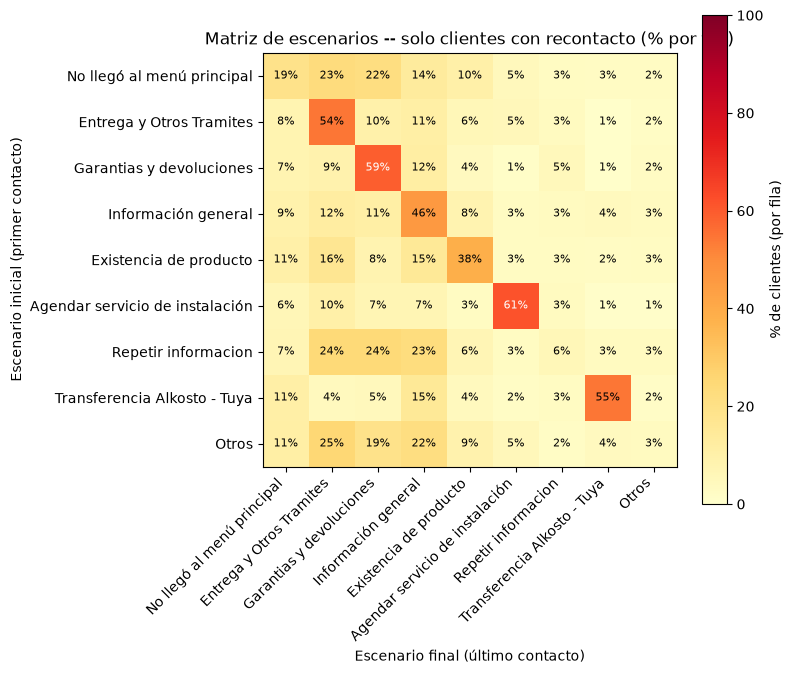

In [32]:
# HeatMap (% por fila -- dado el escenario inicial, dónde termina)
fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(matriz_pct.values, cmap="YlOrRd", vmin=0, vmax=100)

ax.set_xticks(range(len(matriz_pct.columns)))
ax.set_xticklabels(matriz_pct.columns, rotation=45, ha="right")
ax.set_yticks(range(len(matriz_pct.index)))
ax.set_yticklabels(matriz_pct.index)
ax.set_xlabel("Escenario final (último contacto)")
ax.set_ylabel("Escenario inicial (primer contacto)")
ax.set_title("Matriz de escenarios -- solo clientes con recontacto (% por fila)")

for i in range(matriz_pct.shape[0]):
    for j in range(matriz_pct.shape[1]):
        valor = matriz_pct.values[i, j]
        color_texto = "white" if valor > 55 else "black"
        ax.text(j, i, f"{valor:.0f}%", ha="center", va="center", fontsize=8, color=color_texto)

fig.colorbar(im, ax=ax, label="% de clientes (por fila)")
plt.tight_layout()
plt.show()

#### 4.6 Tiempo hasta el recontacto

`df_recontactos` (sección 4) ya trae `horas_desde_contacto_anterior` -- el tiempo entre
cada llamada y la anterior del mismo ANI (para la 1ª llamada de cada cliente queda en
`NaN`, no aplica). Aquí se toma esa columna para todas las llamadas de recontacto
(`numero_llamada > 1`, es decir 2ª vs. 1ª, 3ª vs. 2ª, etc.) y se distribuye en baldes.

In [33]:
# Tiempo entre cada recontacto y el contacto anterior (excluye el primer contacto de cada ANI)
df_tiempo_recontacto = df_recontactos[df_recontactos["numero_llamada"] > 1].copy()
df_tiempo_recontacto["dias_desde_contacto_anterior"] = df_tiempo_recontacto["horas_desde_contacto_anterior"]

print(f"Recontactos analizados: {len(df_tiempo_recontacto):,}")
print(f"Tiempo promedio hasta el recontacto: {df_tiempo_recontacto['dias_desde_contacto_anterior'].mean():.1f} horas")
print(f"Tiempo mediano hasta el recontacto:  {df_tiempo_recontacto['dias_desde_contacto_anterior'].median():.1f} horas")

Recontactos analizados: 64,581
Tiempo promedio hasta el recontacto: 19.0 horas
Tiempo mediano hasta el recontacto:  0.0 horas


In [34]:
# Distribución en baldes de tiempo
def balde_tiempo(horas):
    if pd.isna(horas):
        return None
    if horas <= 24:
        return "0-24 horas"
    dias = horas / 24
    if dias <= 3:
        return "1-3 días"
    if dias <= 7:
        return "3-7 días"
    if dias <= 15:
        return "7-15 días"
    return "15+ días"

df_tiempo_recontacto["balde_tiempo"] = df_tiempo_recontacto["horas_desde_contacto_anterior"].apply(balde_tiempo)

orden_baldes_tiempo = ["0-24 horas", "1-3 días", "3-7 días", "7-15 días", "15+ días"]
distribucion_tiempo = (
    df_tiempo_recontacto.groupby("balde_tiempo")
    .size()
    .reindex(orden_baldes_tiempo)
    .rename("n_recontactos")
    .reset_index()
)
distribucion_tiempo["pct_recontactos"] = (
    distribucion_tiempo["n_recontactos"] / distribucion_tiempo["n_recontactos"].sum() * 100
).round(1)

distribucion_tiempo

,balde_tiempo,n_recontactos,pct_recontactos
0,0-24 horas,54328,84.1
1,1-3 días,5042,7.8
2,3-7 días,3356,5.2
3,7-15 días,1495,2.3
4,15+ días,360,0.6


#### 4.7 Número de recontacto: ¿cambia el comportamiento?

No solo si hubo recontacto, sino si el 2º, 3º, 4º... contacto de un mismo cliente
termina cada vez más en asesor. Se cruza `numero_llamada` (de `df_recontactos`) con
`resultado_final` (de `df_traza`, sección 2). Se agrupan `5°` en adelante por volumen
bajo, y se cuenta "Transferido" como **Transferido a asesor** o **Transferencia directa
(sin pasar por IVR)** -- ambos terminan con un asesor.

In [35]:
RESULTADOS_TRANSFERIDO = ["Transferido a asesor", "Transferencia directa (sin pasar por IVR)"]

df_comportamiento = df_recontactos.merge(
    df_traza[["id_conversacion", "resultado_final"]], on="id_conversacion", how="left"
)
df_comportamiento["transferido"] = df_comportamiento["resultado_final"].isin(RESULTADOS_TRANSFERIDO)

def ordinal_balde(n):
    return f"{n}°" if n < 5 else "5°+"

df_comportamiento["numero_llamada_balde"] = df_comportamiento["numero_llamada"].apply(ordinal_balde)
orden_ordinal = ["1°", "2°", "3°", "4°", "5°+"]

df_comportamiento[["numero_llamada", "numero_llamada_balde", "resultado_final", "transferido"]].head()

,numero_llamada,numero_llamada_balde,resultado_final,transferido
0,1,1°,Resuelto en IVR,False
1,1,1°,Transferido a asesor,True
2,2,2°,Transferido a asesor,True
3,3,3°,Transferido a asesor,True
4,4,4°,Transferido a asesor,True


In [36]:
# Tabla principal: % transferido a asesor, por número de contacto
tabla_comportamiento = (
    df_comportamiento.groupby("numero_llamada_balde")
    .agg(llamadas=("id_conversacion", "size"), transferidos=("transferido", "sum"))
    .reindex(orden_ordinal)
    .reset_index()
    .rename(columns={"numero_llamada_balde": "Recontacto"})
)
tabla_comportamiento["% Transferido"] = (
    tabla_comportamiento["transferidos"] / tabla_comportamiento["llamadas"] * 100
).round(1)

tabla_comportamiento

,Recontacto,llamadas,transferidos,% Transferido
0,1°,40918,22552,55.1
1,2°,17466,10495,60.1
2,3°,8813,5465,62.0
3,4°,4980,3177,63.8
4,5°+,33322,26398,79.2


In [37]:
# Detalle completo: distribución de resultado_final por número de contacto (% por fila)
tabla_detalle = pd.crosstab(
    df_comportamiento["numero_llamada_balde"], df_comportamiento["resultado_final"], normalize="index"
) * 100
tabla_detalle = tabla_detalle.reindex(orden_ordinal).round(1)
tabla_detalle

resultado_final,Abandono / sin respuesta,Cliente colgó en navegación,Colgó antes de cualquier navegación,Error técnico,Resuelto en IVR,Transferencia directa (sin pasar por IVR),Transferido a asesor
numero_llamada_balde,,,,,,,
1°,6.0,17.0,0.5,2.8,18.6,0.2,54.9
2°,4.6,15.4,0.6,3.6,15.7,0.5,59.6
3°,4.1,14.3,0.8,4.3,14.6,0.9,61.1
4°,4.2,13.0,0.8,5.3,12.9,1.7,62.1
5°+,2.0,7.2,0.5,4.1,7.0,22.4,56.8


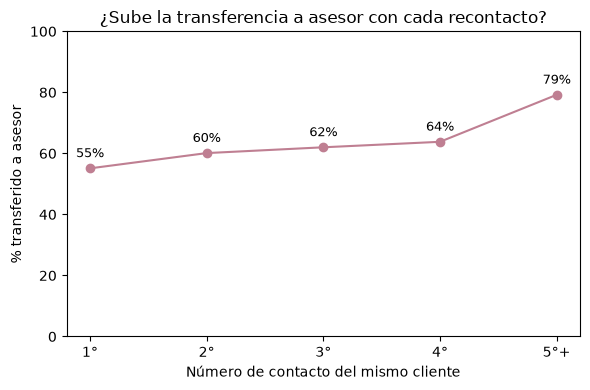

In [38]:
# Gráfico de línea: ¿el % transferido sube con cada recontacto sucesivo?
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(tabla_comportamiento["Recontacto"], tabla_comportamiento["% Transferido"], marker="o", color="#bf7f92")
for _, fila in tabla_comportamiento.iterrows():
    ax.annotate(f"{fila['% Transferido']:.0f}%", (fila["Recontacto"], fila["% Transferido"]),
                textcoords="offset points", xytext=(0, 8), ha="center", fontsize=9)
ax.set_xlabel("Número de contacto del mismo cliente")
ax.set_ylabel("% transferido a asesor")
ax.set_title("¿Sube la transferencia a asesor con cada recontacto?")
ax.set_ylim(0, 100)
plt.tight_layout()
plt.show()

#### 4.8 Top OP_TEXT finales -- usuarios con recontacto

Toma **todas las conversaciones** (no solo la última) de los ANI clasificados como
`Recontacto` en 4.1, y rankea el `ultimo_texto` de cada una (ya calculado en la sección 2,
a partir de `ultima_opcion`) -- ese es el nodo/paso en el que terminó cada llamada. Sirve
para ver qué resultados dominan entre los clientes que sí insisten con más de un
contacto.

In [39]:
anis_recontacto = df_ani_contactos.loc[df_ani_contactos["tipo_cliente"] == "Recontacto", "ani"]

df_traza_recontacto = df_traza[df_traza["ani"].isin(anis_recontacto)].copy()
df_traza_recontacto["ultimo_texto_final"] = df_traza_recontacto["ultimo_texto"].fillna("Sin navegación registrada")

print(f"Conversaciones de clientes con recontacto: {len(df_traza_recontacto):,}")
print(f"  (de {anis_recontacto.nunique():,} clientes distintos)")

Conversaciones de clientes con recontacto: 82,047
  (de 17,466 clientes distintos)


In [40]:
# Ranking de op_text final
top_op_text_final = (
    df_traza_recontacto.groupby("ultimo_texto_final")
    .size()
    .rename("n_conversaciones")
    .reset_index()
    .rename(columns={"ultimo_texto_final": "op_text_final"})
    .sort_values("n_conversaciones", ascending=False)
    .reset_index(drop=True)
)
top_op_text_final["pct"] = (
    top_op_text_final["n_conversaciones"] / top_op_text_final["n_conversaciones"].sum() * 100
).round(1)

TOP_N = 20
top_op_text_final.head(TOP_N)

,op_text_final,n_conversaciones,pct
0,Finalización por fin de flujo,13569,16.5
1,Primera pregunta SAC,10842,13.2
2,Sin navegación registrada,8266,10.1
3,Paso agente SAC,7081,8.6
4,Existencia de producto,4968,6.1
5,Paso agente despachos,4502,5.5
6,Inicio IVR,4352,5.3
7,No input,3510,4.3
8,Finalización por error en el flujo,3402,4.1
9,Paso agente garantias,2677,3.3


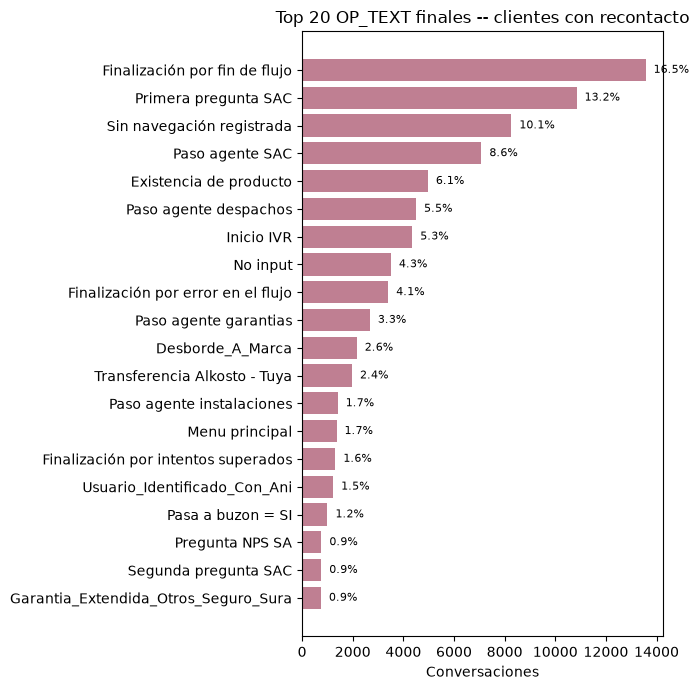

In [41]:
# Gráfico -- top N op_text finales
datos_grafico_op_text = top_op_text_final.head(TOP_N).sort_values("n_conversaciones", ascending=True)

fig, ax = plt.subplots(figsize=(7, max(3, 0.35 * len(datos_grafico_op_text))))
ax.barh(datos_grafico_op_text["op_text_final"], datos_grafico_op_text["n_conversaciones"], color="#bf7f92")
for i, fila in datos_grafico_op_text.reset_index(drop=True).iterrows():
    ax.text(fila["n_conversaciones"], i, f"  {fila['pct']:.1f}%", va="center", fontsize=8)
ax.set_xlabel("Conversaciones")
ax.set_title(f"Top {TOP_N} OP_TEXT finales -- clientes con recontacto")
plt.tight_layout()
plt.show()

### 5. Consolidar `df_resumen`

In [42]:
df_resumen = (
    df_traza
    .merge(escenarios, on="id_conversacion", how="left")
    .merge(subescenarios, on="id_conversacion", how="left")
    .merge(n_pasos, on="id_conversacion", how="left")
    .merge(df_recontactos, on="id_conversacion", how="left")
    .merge(
        df_ani_contactos[["ani", "tipo_cliente", "balde_contactos"]],
        on="ani", how="left",
    )
    .merge(
        df_primer_contacto.rename(columns={"escenario_inicial": "escenario_inicial_cliente"}),
        on="ani", how="left",
    )
)

df_resumen["escenario"] = df_resumen["escenario"].fillna("No lleg\u00f3 al men\u00fa principal")
df_resumen["subescenario"] = df_resumen["subescenario"].fillna("Sin sub-escenario")
df_resumen["n_pasos"] = df_resumen["n_pasos"].fillna(0).astype(int)
df_resumen["escenario_inicial_cliente"] = df_resumen["escenario_inicial_cliente"].fillna("No lleg\u00f3 al men\u00fa principal")

print(f"df_resumen: {df_resumen.shape}")
print("Columnas de recontacto agregadas: tipo_cliente, balde_contactos, escenario_inicial_cliente")
df_resumen.head(3)

df_resumen: (105499, 74)
Columnas de recontacto agregadas: tipo_cliente, balde_contactos, escenario_inicial_cliente


,id_conversacion,ani,nombre_ivr,fecha_hora_ingreso,fecha_hora_fin,duracion_ivr,duracion_navegacion,duracion_transaccional,duracion_paso_ce,duracion_desborde,traza_opciones,ultima_opcion,paso_ce,tipo_desconexion,fecha_inicio,fecha_fin,traza_1,traza_2,traza_3,traza_4,traza_5,traza_6,traza_7,traza_8,traza_9,traza_10,traza_11,traza_12,traza_13,traza_14,traza_15,traza_16,traza_17,traza_18,traza_19,traza_20,traza_21,traza_22,traza_23,traza_24,traza_25,traza_26,traza_27,traza_28,traza_29,traza_30,traza_31,traza_32,traza_33,traza_34,traza_35,traza_36,traza_37,traza_38,traza_39,traza_40,traza_41,traza_42,traza_43,traza_44,ultimo_codigo,ultimo_texto,paso_por_ivr,resultado_final,escenario,subescenario,n_pasos,n_contactos_ani,numero_llamada,horas_desde_contacto_anterior,unico_contacto,tipo_cliente,balde_contactos,escenario_inicial_cliente
0,891f883b-e8c0-4a43-91a8-00f93459a745,+573212202672,"ALK_IVR_PRINCIPAL,Default In-Queue Flow Alkost...",2026-06-01 18:51:32.530,2026-06-01 19:03:54.720,185663,185095.0,1496.0,284.0,0.0,|0;Inicio IVR ;0|3;Habeas data positivo;48030|...,1003;Finalización por fin de flujo;31,SI,System,2026-06-01,2026-06-01,Inicio IVR,Habeas data positivo,Menu principal,Garantias y devoluciones,Repetir informacion,Repeat,Iniciar_Tu_Garantia,Igual_O_Menor_30_Dias,Producto_Deteriorado,Gran_Tamano,Paso agente garantias,Bienvenida encuesta SAC,Primera pregunta SAC,Segunda pregunta SAC,Pasa a buzon = NO,Finalización por fin de flujo,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1003,Finalización por fin de flujo,True,Transferido a asesor,Garantias y devoluciones,Repetir informacion,16,1,1,NaN,True,Contacto único,1,Garantias y devoluciones
1,87da4cf9-0f24-4bfa-ac8d-89fb352833e8,680f7a988560a0625a90572d+emtelcosas.orgspan.co...,ALK_IVR_ENCUESTA_SAC,2026-06-01 11:14:39.923,2026-06-01 11:17:15.120,80,NaN,NaN,NaN,NaN,NaN,NaN,SI,External,2026-06-01,2026-06-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,Transferencia directa (sin pasar por IVR),No llegó al menú principal,Sin sub-escenario,0,19,2,1.825656,False,Recontacto,5+,No llegó al menú principal
2,0db1a400-045e-486b-812a-124eacf99f90,+573187789584,"ALK_IVR_PRINCIPAL,Default In-Queue Flow Alkosto",2026-06-01 16:35:06.287,2026-06-01 17:06:25.677,42416,41932.0,1325.0,242.0,0.0,|0;Inicio IVR ;0|17;Menu principal;14164|161;E...,205;Paso agente despachos;157,SI,External,2026-06-01,2026-06-01,Inicio IVR,Menu principal,Entrega y Otros Tramites,Estado de entrega,¿Factura encontrada? = SI,¿Total de facturas mayor a uno? = SI,Paso agente despachos,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,205,Paso agente despachos,True,Transferido a asesor,Entrega y Otros Tramites,Estado de entrega,7,2,2,-0.001107,False,Recontacto,2,No match


In [43]:
# Chequeo cruzado rápido: escenario x resultado_final -- para calibrar antes de exportar
pd.crosstab(df_resumen["escenario"], df_resumen["resultado_final"])

resultado_final,Abandono / sin respuesta,Cliente colgó en navegación,Colgó antes de cualquier navegación,Error técnico,Resuelto en IVR,Transferencia directa (sin pasar por IVR),Transferido a asesor
escenario,,,,,,,
Agendar servicio de instalación,0,0,0,0,238,0,3863
Entrega y Otros Tramites,628,1965,0,2027,2223,0,14519
Existencia de producto,0,141,0,564,6676,0,0
Garantias y devoluciones,292,1607,0,265,2233,0,14110
Información general,47,453,0,10,1341,0,8659
No input,241,64,0,20,208,0,854
No llegó al menú principal,3216,9443,555,639,761,7793,13400
No match,51,28,0,22,102,0,342
Repetir informacion,40,276,0,89,519,0,2036


### 6. Tabla de aristas (origen → destino) para el grafo

`op_text_final` = el siguiente paso dentro de la misma conversación (`shift(-1)`); la última
fila de cada conversación se marca como `"final"`. Esto reemplaza la función
`transformar_dataframe` de `01_Alk_final.ipynb` (2024).

In [44]:
df_aristas = (
    df_pasos[df_pasos["es_negocio"]]
    .sort_values(["id_conversacion", "bloque"])
    .copy()
)
df_aristas["op_text_final"] = df_aristas.groupby("id_conversacion")["op_text"].shift(-1)

ultimas_filas = df_aristas.groupby("id_conversacion").tail(1).index
df_aristas.loc[ultimas_filas, "op_text_final"] = "final"

print(f"df_aristas: {df_aristas.shape}  (de {len(df_pasos):,} pasos totales, {len(df_pasos[df_pasos['es_negocio']]):,} son de negocio)")
df_aristas.head(10)

df_aristas: (600411, 8)  (de 812,203 pasos totales, 600,411 son de negocio)


,id_conversacion,bloque,op_num,op_text,op_tiempo,categoria_nodo,es_negocio,op_text_final
73467,0000b8f3-39e8-4388-aa08-23c0031a9d9f,0,0,Inicio IVR,0,Navegación/Negocio,True,Menu principal
73469,0000b8f3-39e8-4388-aa08-23c0031a9d9f,2,17,Menu principal,604,Navegación/Negocio,True,Agendar servicio de instalación
73470,0000b8f3-39e8-4388-aa08-23c0031a9d9f,3,11,Agendar servicio de instalación,18954,Navegación/Negocio,True,Paso agente instalaciones
73471,0000b8f3-39e8-4388-aa08-23c0031a9d9f,4,206,Paso agente instalaciones,124,Navegación/Negocio,True,final
760613,0001de09-fc90-45b0-a909-29c583544af1,0,0,Inicio IVR,0,Navegación/Negocio,True,final
70872,0001f83b-86fd-464d-a881-df45bb9181bf,0,0,Inicio IVR,0,Navegación/Negocio,True,Menu principal
70873,0001f83b-86fd-464d-a881-df45bb9181bf,1,17,Menu principal,16586,Navegación/Negocio,True,Entrega y Otros Tramites
70874,0001f83b-86fd-464d-a881-df45bb9181bf,2,161,Entrega y Otros Tramites,10688,Navegación/Negocio,True,Estado de entrega
70875,0001f83b-86fd-464d-a881-df45bb9181bf,3,6,Estado de entrega,8862,Navegación/Negocio,True,¿Factura encontrada? = SI
70876,0001f83b-86fd-464d-a881-df45bb9181bf,4,301,¿Factura encontrada? = SI,1637,Navegación/Negocio,True,¿Total de facturas mayor a uno? = SI


### 7. Exportar

In [45]:
df_resumen.to_parquet(OUT_RESUMEN_PATH, index=False)
df_aristas.to_parquet(OUT_ARISTAS_PATH, index=False)

print("Guardado:")
print(f"  {OUT_RESUMEN_PATH} -> {df_resumen.shape}  (insumo del tablero Power BI)")
print(f"  {OUT_ARISTAS_PATH} -> {df_aristas.shape}  (insumo del grafo, filtrar por escenario aquí)")

# Muestras en Excel para revisión manual
df_resumen.head(500).to_excel(SEG_DIR / f"df_resumen_muestra_{FECHA_INICIO}_{FECHA_FIN}.xlsx", index=False)
df_aristas.head(500).to_excel(SEG_DIR / f"df_aristas_muestra_{FECHA_INICIO}_{FECHA_FIN}.xlsx", index=False)

Guardado:
  data\02_segmentacion\df_resumen_2026-06-01_2026-06-30.parquet -> (105499, 74)  (insumo del tablero Power BI)
  data\02_segmentacion\df_aristas_2026-06-01_2026-06-30.parquet -> (600411, 8)  (insumo del grafo, filtrar por escenario aquí)


# 03 · Grafos de navegación — IVR Alkosto

Toma `df_aristas` y `df_resumen` (salidas de `02_segmentacion.ipynb`) y dibuja el grafo
dirigido de navegación con `graphviz`, igual que `02_Grafos.ipynb` de 2024, pero con dos
diferencias:
- Lee directamente los parquet del pipeline nuevo -- no hace falta generar un Excel filtrado
  por escenario a mano.
- El filtro por escenario (`ESCENARIO`, celda de parámetros) reemplaza el "cambiar la ruta y
  volver a correr" de 2024: se filtra `df_aristas` por `id_conversacion` usando `escenario` de
  `df_resumen` antes de agrupar.

**Entradas:** `df_aristas_<periodo>.parquet`, `df_resumen_<periodo>.parquet`

**Salida:** `.gv` / `.gv.pdf` del grafo (todo el IVR, o un escenario específico).

In [1]:
import re
import graphviz
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from pathlib import Path

#### Parámetros

- `ESCENARIO = None` grafica el IVR completo. Fija un valor exacto de
  `df_resumen["escenario"]` para filtrar a esa rama.
- `SUBESCENARIO = None` -- si el escenario sigue teniendo demasiados nodos, fija además un
  valor exacto de `df_resumen["subescenario"]` (el paso siguiente al escenario) para acotar
  más. Requiere `ESCENARIO` fijado.
- `MIN_FRECUENCIA` -- oculta aristas que ocurrieron menos de N veces. Es el ajuste principal
  para la legibilidad: sube este número si el grafo sigue muy denso.

Corre la celda de abajo para ver las opciones disponibles antes de fijar los valores.

In [6]:
FECHA_INICIO = "2026-06-01"
FECHA_FIN = "2026-06-30"
ESCENARIO = "Garantias y devoluciones"          # ej. "Garantias y devoluciones" -- None = todo el IVR
SUBESCENARIO = None      # ej. "Estado_De_Tu_Garantia" -- requiere ESCENARIO fijado
MIN_FRECUENCIA = 100        # sube este número (ej. 5, 10, 20) si el grafo queda muy denso

DATA_DIR = Path("../data") if Path("../data").exists() else Path("data")
SEG_DIR = DATA_DIR / "02_segmentacion"
GRAFOS_DIR = DATA_DIR / "03_grafos"
GRAFOS_DIR.mkdir(parents=True, exist_ok=True)

IN_ARISTAS_PATH = SEG_DIR / f"df_aristas_{FECHA_INICIO}_{FECHA_FIN}.parquet"
IN_RESUMEN_PATH = SEG_DIR / f"df_resumen_{FECHA_INICIO}_{FECHA_FIN}.parquet"

for p in (IN_ARISTAS_PATH, IN_RESUMEN_PATH):
    assert p.exists(), f"No encuentro {p} -- corre primero 02_segmentacion.ipynb"

In [4]:
df_aristas = pd.read_parquet(IN_ARISTAS_PATH)
df_resumen = pd.read_parquet(IN_RESUMEN_PATH)

print(f"df_aristas: {df_aristas.shape}")
print(f"df_resumen: {df_resumen.shape}")

# Menú completo de escenario x subescenario -- de aquí sacas los valores exactos para
# ESCENARIO y SUBESCENARIO en la celda de parámetros. Siempre se imprime, sin importar lo
# que hayas puesto arriba.
menu_escenarios = (
    df_resumen.groupby(["escenario", "subescenario"])
    .size()
    .rename("n_conversaciones")
    .reset_index()
    .sort_values(["n_conversaciones"], ascending=[False])
)
pd.set_option("display.max_rows", 200)
menu_escenarios.head(10)

df_aristas: (600411, 8)
df_resumen: (105499, 74)


,escenario,subescenario,n_conversaciones
44,No llegó al menú principal,Sin sub-escenario,35807
4,Entrega y Otros Tramites,Estado de entrega,14734
15,Garantias y devoluciones,Iniciar_Tu_Garantia,8357
28,Información general,Paso agente SAC,8213
11,Existencia de producto,Sin sub-escenario,6817
1,Agendar servicio de instalación,Paso agente instalaciones,3863
13,Garantias y devoluciones,Estado_De_Tu_Garantia,3705
57,Repetir informacion,Repeat,2960
60,Transferencia Alkosto - Tuya,Sin sub-escenario,2511
5,Entrega y Otros Tramites,Menu principal,2262


### Filtrar por escenario (si aplica) y calcular frecuencia de cada arista

La frecuencia cuenta **ocurrencias del par (origen, destino)**, no conversaciones únicas --
si una llamada pasa dos veces por el mismo par (ej. "Repetir informacion"), cuenta dos veces.
Es la misma lógica que usaba `02_Grafos.ipynb` en 2024 (`groupby().count()`).

In [7]:
mascara = pd.Series(True, index=df_resumen.index)
if ESCENARIO is not None:
    mascara &= df_resumen["escenario"] == ESCENARIO
if SUBESCENARIO is not None:
    assert ESCENARIO is not None, "SUBESCENARIO requiere que fijes ESCENARIO también"
    mascara &= df_resumen["subescenario"] == SUBESCENARIO

ids_filtrados = df_resumen.loc[mascara, "id_conversacion"]
assert len(ids_filtrados) > 0, "El filtro de escenario/subescenario no dejó ninguna conversación"
df_aristas_filtrado = df_aristas[df_aristas["id_conversacion"].isin(ids_filtrados)]

resultado_completo = (
    df_aristas_filtrado
    .groupby(["op_text", "op_text_final"])
    .agg(frecuencia=("id_conversacion", "count"))
    .sort_values("frecuencia", ascending=False)
    .reset_index()
)

resultado = resultado_completo[resultado_completo["frecuencia"] >= MIN_FRECUENCIA]

volumen_total = resultado_completo["frecuencia"].sum()
volumen_mostrado = resultado["frecuencia"].sum()

print(f"Escenario: {ESCENARIO or 'TODO EL IVR'} / Sub-escenario: {SUBESCENARIO or '(todos)'}")
print(f"{df_aristas_filtrado['id_conversacion'].nunique():,} conversaciones")
print(f"Aristas: {len(resultado_completo)} totales -> {len(resultado)} con MIN_FRECUENCIA >= {MIN_FRECUENCIA}")
print(f"Volumen representado: {volumen_mostrado:,} de {volumen_total:,} transiciones ({volumen_mostrado/volumen_total*100:.1f}%)")
resultado.tail()

Escenario: Garantias y devoluciones / Sub-escenario: (todos)
18,507 conversaciones
Aristas: 321 totales -> 99 con MIN_FRECUENCIA >= 100
Volumen representado: 135,071 de 139,133 transiciones (97.1%)


,op_text,op_text_final,frecuencia
94,Repetir informacion,Paso agente SAC,104
95,Pequeno,Menu principal,104
96,Iniciar_Tu_Garantia,Repetir informacion,102
97,Repetir informacion,Pequeno,102
98,¿Estado fraude? = NO,Transportador Alkosto,100


### Construir el grafo

Mismo esquema de color que 2024: escala `YlOrRd` normalizada en log sobre el volumen total
que recibe cada nodo, para que los puntos más transitados se vean "más calientes".

In [8]:
import os
os.environ["PATH"] = r"C:\Program Files (x86)\Graphviz\bin" + os.pathsep + os.environ["PATH"]
#Para agregar al path de Windows (PowerShell) y que Graphviz funcione en Jupyter Notebook
# #$env:PATH = "C:\Program Files (x86)\Graphviz\bin;$env:PATH"
#Test-Path "C:\Program Files (x86)\Graphviz\bin\dot.exe"

Guardado: data\03_grafos\grafo_garantias_y_devoluciones_2026-06-01_2026-06-30.gv.pdf


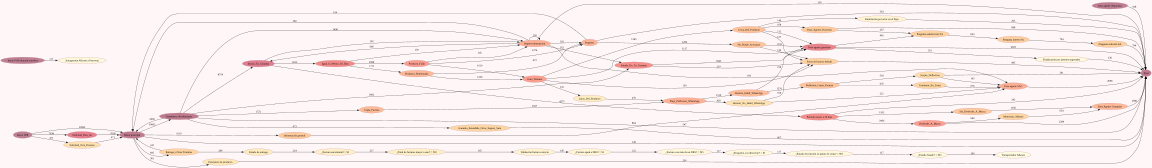

In [9]:
cmap = plt.colormaps["YlOrRd"]
norm = mcolors.Normalize(
    vmin=np.log(resultado["frecuencia"].min()),
    vmax=np.log(resultado["frecuencia"].max()),
)

sufijo = "_".join(filter(None, [ESCENARIO, SUBESCENARIO])) or "todo_ivr"
nombre_archivo = f"grafo_{sufijo.lower().replace(' ', '_')}_{FECHA_INICIO}_{FECHA_FIN}"

u = graphviz.Digraph(
    "ivr",
    filename=str(GRAFOS_DIR / f"{nombre_archivo}.gv"),
    node_attr={"color": "#bf7f92", "style": "filled"},
)
# Con pocos niveles de profundidad (ej. sub-escenarios chicos) 'LR' puede quedar muy ancho y
# aplastado -- si eso pasa, prueba "TB" (arriba-abajo, el original) o ajusta el tamaño abajo.
u.attr(size="16,10")
u.attr(ratio="compress")
u.attr(bgcolor="#fff7f7")
u.attr(rankdir="LR")
u.attr(nodesep="0.25")
u.attr(ranksep="0.6")

for _, fila in resultado.iterrows():
    u.edge(fila["op_text"], fila["op_text_final"], label=str(fila["frecuencia"]))

for nodo_destino in resultado["op_text_final"].unique():
    volumen = resultado.loc[resultado["op_text_final"] == nodo_destino, "frecuencia"].sum()
    color = mcolors.to_hex(cmap(norm(np.log(volumen))))
    u.node(nodo_destino, fillcolor=color + "80")

u.render(cleanup=True)  # genera el .pdf sin intentar abrirlo (usa u.view() si prefieres que se abra)
print(f"Guardado: {GRAFOS_DIR / (nombre_archivo + '.gv.pdf')}")
u

Guardado: data\03_grafos\grafo_garantias_y_devoluciones_2026-06-01_2026-06-30.gv.png


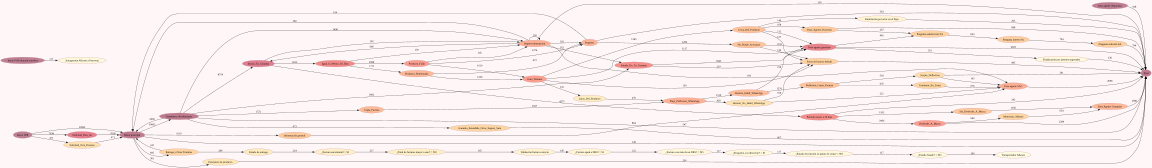

In [10]:
cmap = plt.colormaps["YlOrRd"]
norm = mcolors.Normalize(
    vmin=np.log(resultado["frecuencia"].min()),
    vmax=np.log(resultado["frecuencia"].max()),
)

sufijo = "_".join(filter(None, [ESCENARIO, SUBESCENARIO])) or "todo_ivr"
nombre_archivo = f"grafo_{sufijo.lower().replace(' ', '_')}_{FECHA_INICIO}_{FECHA_FIN}"

u = graphviz.Digraph(
    "ivr",
    filename=str(GRAFOS_DIR / f"{nombre_archivo}.gv"),
    format="png",  # PNG en vez de PDF -- se inserta directo como imagen en Power BI / PowerPoint
    node_attr={"color": "#bf7f92", "style": "filled"},
)
# Con pocos niveles de profundidad (ej. sub-escenarios chicos) 'LR' puede quedar muy ancho y
# aplastado -- si eso pasa, prueba "TB" (arriba-abajo, el original) o ajusta el tama\u00f1o abajo.
u.attr(size="16,10")
u.attr(ratio="compress")
u.attr(bgcolor="#fff7f7")
u.attr(rankdir="LR")
u.attr(nodesep="0.25")
u.attr(ranksep="0.6")

for _, fila in resultado.iterrows():
    u.edge(fila["op_text"], fila["op_text_final"], label=str(fila["frecuencia"]))

for nodo_destino in resultado["op_text_final"].unique():
    volumen = resultado.loc[resultado["op_text_final"] == nodo_destino, "frecuencia"].sum()
    color = mcolors.to_hex(cmap(norm(np.log(volumen))))
    u.node(nodo_destino, fillcolor=color + "80")

u.render(cleanup=True)  # genera el .png sin intentar abrirlo (usa u.view() si prefieres que se abra)
print(f"Guardado: {GRAFOS_DIR / (nombre_archivo + '.gv.png')}")
u

## Tabla de puntos de fuga (por escenario y nodo)

Traduce el grafo a números planos para Power BI: una fila por (`escenario`, `nodo`), con
cuántas veces se llegó a ese nodo y qué pasó después, en 3 grandes grupos:

- **`sigue_navegando`**: la siguiente parada fue otro nodo real del árbol.
- **`va_a_asesor_nodo`**: la siguiente parada es un nodo que ya es de asesor ("Paso agente...",
  "Desborde...", "Transferencia...") -- todavía sigue "dentro" del grafo, no cuelga ahí.
- **`termina_<resultado_final>`**: ese nodo fue el **último** de la conversación (`op_text_final
  == "final"`). En vez de adivinar por el texto del nodo, se usa el `resultado_final` ya
  validado de esa conversación específica (Resuelto en IVR / Transferido a asesor / Abandono /
  Cliente colgó / Error técnico) -- por eso corre después de tener `df_resumen`.

No corre sobre `resultado` (que ya está filtrado por `ESCENARIO`) sino sobre `df_aristas`
completo, para poder comparar puntos de fuga *entre* escenarios en el mismo tablero.

In [53]:
import re

patron_asesor_nodo = re.compile(r"paso[_\s]*agente|desborde|transferencia", re.IGNORECASE)

mapa_resultado_corto = {
    "Transferido a asesor": "transferido_asesor",
    "Resuelto en IVR": "resuelto_ivr",
    "Cliente colgó en navegación": "colgo_navegacion",
    "Abandono / sin respuesta": "abandono_sin_respuesta",
    "Error técnico": "error_tecnico",
    "Sin navegación registrada": "sin_navegacion_registrada",
    "Otro / sin clasificar": "otro_sin_clasificar",
}

def categoria_salida(fila):
    if fila["op_text_final"] == "final":
        etiqueta = mapa_resultado_corto.get(fila["resultado_final"], "otro_sin_clasificar")
        return f"termina_{etiqueta}"
    if patron_asesor_nodo.search(str(fila["op_text_final"])):
        return "va_a_asesor_nodo"
    return "sigue_navegando"

df_aristas_con_resultado = df_aristas.merge(
    df_resumen[["id_conversacion", "escenario", "resultado_final"]], on="id_conversacion", how="left"
)
df_aristas_con_resultado["categoria_salida"] = df_aristas_con_resultado.apply(categoria_salida, axis=1)

conteo = (
    df_aristas_con_resultado
    .groupby(["escenario", "op_text", "categoria_salida"])
    .size()
    .rename("frecuencia")
    .reset_index()
)

tabla_pivot = conteo.pivot_table(
    index=["escenario", "op_text"], columns="categoria_salida", values="frecuencia", fill_value=0
)
tabla_pivot["llegadas"] = tabla_pivot.sum(axis=1)

pct = tabla_pivot.drop(columns="llegadas").div(tabla_pivot["llegadas"], axis=0) * 100
pct = pct.add_prefix("pct_").round(1)

df_puntos_fuga = pd.concat([tabla_pivot["llegadas"], pct], axis=1).reset_index()
df_puntos_fuga = df_puntos_fuga.rename(columns={"op_text": "nodo"}).sort_values("llegadas", ascending=False)

print(f"{len(df_puntos_fuga)} filas (escenario x nodo)")
df_puntos_fuga.head(15)

822 filas (escenario x nodo)


,escenario,nodo,llegadas,pct_sigue_navegando,pct_termina_abandono_sin_respuesta,pct_termina_colgo_navegacion,pct_termina_error_tecnico,pct_termina_resuelto_ivr,pct_termina_transferido_asesor,pct_va_a_asesor_nodo
70,Entrega y Otros Tramites,Menu principal,24979.0,98.9,0.1,0.5,0.0,0.0,0.0,0.5
43,Entrega y Otros Tramites,Entrega y Otros Tramites,21908.0,96.9,0.6,2.1,0.0,0.0,0.0,0.5
224,Garantias y devoluciones,Menu principal,21465.0,99.1,0.1,0.5,0.0,0.0,0.0,0.3
65,Entrega y Otros Tramites,Inicio IVR,21074.0,100.0,0.0,0.0,0.0,0.0,0.0,0.0
209,Garantias y devoluciones,Garantias y devoluciones,19088.0,96.8,0.6,2.2,0.0,0.0,0.0,0.3
220,Garantias y devoluciones,Inicio IVR,18371.0,100.0,0.0,0.0,0.0,0.0,0.0,0.0
44,Entrega y Otros Tramites,Estado de entrega,15953.0,98.9,0.0,0.0,0.0,0.0,0.0,1.1
535,No llegó al menú principal,Inicio IVR,13599.0,14.4,21.9,52.4,0.0,0.0,0.0,11.3
129,Entrega y Otros Tramites,¿Factura encontrada? = SI,12617.0,100.0,0.0,0.0,0.0,0.0,0.0,0.0
536,No llegó al menú principal,Inicio IVR inbound transfers,12234.0,97.7,0.0,0.0,0.0,2.3,0.0,0.0


In [54]:
OUT_PUNTOS_FUGA_PATH = GRAFOS_DIR / f"df_puntos_fuga_{FECHA_INICIO}_{FECHA_FIN}.parquet"
df_puntos_fuga.to_parquet(OUT_PUNTOS_FUGA_PATH, index=False)
df_puntos_fuga.to_excel(GRAFOS_DIR / f"df_puntos_fuga_{FECHA_INICIO}_{FECHA_FIN}.xlsx", index=False)
print(f"Guardado: {OUT_PUNTOS_FUGA_PATH} -> {df_puntos_fuga.shape}")

Guardado: data\03_grafos\df_puntos_fuga_2026-06-01_2026-06-30.parquet -> (822, 10)


## Tabla de puntos de fuga (para Power BI)

El grafo es para *ver* dónde está la fricción; esta tabla es para *cuantificarla*. Por cada
`(escenario, nodo)` calcula:
- **`llegadas`**: cuántas veces una conversación llegó a ese nodo (desde cualquier origen).
- **% de lo que sale de ese nodo** que:
  - `Continúa en el flujo` -- sigue navegando a otro nodo real.
  - `Transferido a asesor` -- el siguiente paso es un nodo de paso a asesor/desborde/
    transferencia (aplica tanto si es un nodo intermedio como si fue el último paso real de
    la conversación).
  - `Resuelto en IVR`, `Cliente colgó en navegación`, `Abandono / sin respuesta`,
    `Error técnico`, `Sin navegación registrada` -- la conversación **terminó justo en ese
    nodo** (no hay paso siguiente registrado); se usa el `resultado_final` ya calculado en la
    sección 2 para saber cómo terminó exactamente.

Con esto puedes armar directamente un ranking tipo "nodo con más llegadas y mayor % a
asesor" -- los candidatos más claros a mejorar el autoservicio.

In [13]:
# --- Tabla de puntos de fuga por nodo ---

patron_asesor = re.compile(r"paso[_\s]*agente|desborde|transferencia", re.IGNORECASE)

mapa_escenario = df_resumen.set_index("id_conversacion")["escenario"]
mapa_resultado = df_resumen.set_index("id_conversacion")["resultado_final"]

df_flujo = df_aristas.copy()
df_flujo["escenario"] = df_flujo["id_conversacion"].map(mapa_escenario)

es_final = df_flujo["op_text_final"] == "final"
es_asesor_intermedio = df_flujo["op_text_final"].str.contains(patron_asesor, na=False)

df_flujo["tipo_destino"] = np.select(
    [es_final, es_asesor_intermedio],
    [df_flujo["id_conversacion"].map(mapa_resultado), "Transferido a asesor"],
    default="Continúa en el flujo",
)

# Llegadas: cuántas veces se llegó a cada nodo real (excluye el marcador "final", que no es un nodo)
llegadas = (
    df_flujo[df_flujo["op_text_final"] != "final"]
    .groupby(["escenario", "op_text_final"])
    .size()
    .rename("llegadas")
    .reset_index()
    .rename(columns={"op_text_final": "nodo"})
)

# Salidas: qué pasa con lo que sale de cada nodo, como % del total de salidas de ese nodo
salidas = (
    df_flujo.groupby(["escenario", "op_text", "tipo_destino"])
    .size()
    .rename("volumen")
    .reset_index()
)
tabla_pct = salidas.pivot_table(
    index=["escenario", "op_text"], columns="tipo_destino", values="volumen", fill_value=0
)
tabla_pct["salidas_totales"] = tabla_pct.sum(axis=1)
columnas_pct = [c for c in tabla_pct.columns if c != "salidas_totales"]
tabla_pct[columnas_pct] = tabla_pct[columnas_pct].div(tabla_pct["salidas_totales"], axis=0) * 100
tabla_pct = tabla_pct.round(1).reset_index().rename(columns={"op_text": "nodo"})

tabla_fuga = llegadas.merge(tabla_pct, on=["escenario", "nodo"], how="outer")
tabla_fuga = tabla_fuga.sort_values("llegadas", ascending=False)

print(f"{len(tabla_fuga):,} filas (escenario x nodo)")
tabla_fuga.head(15)

822 filas (escenario x nodo)


,escenario,nodo,llegadas,Abandono / sin respuesta,Cliente colgó en navegación,Continúa en el flujo,Error técnico,Resuelto en IVR,Transferido a asesor,salidas_totales
70,Entrega y Otros Tramites,Menu principal,24979.0,0.1,0.5,98.9,0.0,0.0,0.5,24979.0
43,Entrega y Otros Tramites,Entrega y Otros Tramites,21908.0,0.6,2.1,96.9,0.0,0.0,0.5,21908.0
224,Garantias y devoluciones,Menu principal,21465.0,0.1,0.5,99.1,0.0,0.0,0.3,21465.0
209,Garantias y devoluciones,Garantias y devoluciones,19088.0,0.6,2.2,96.8,0.0,0.0,0.3,19088.0
44,Entrega y Otros Tramites,Estado de entrega,15953.0,0.0,0.0,98.9,0.0,0.0,1.1,15953.0
129,Entrega y Otros Tramites,¿Factura encontrada? = SI,12617.0,0.0,0.0,100.0,0.0,0.0,0.0,12617.0
138,Entrega y Otros Tramites,¿Total de facturas mayor a uno? = NO,10836.0,0.9,0.8,97.0,0.0,0.0,1.3,10836.0
366,Información general,Menu principal,10669.0,0.0,0.1,99.8,0.0,0.0,0.0,10669.0
333,Información general,Información general,10562.0,0.3,2.1,18.0,0.0,0.0,79.6,10562.0
80,Entrega y Otros Tramites,Paso agente despachos,10199.0,0.0,0.0,1.5,0.0,0.0,98.5,10199.0


In [56]:
OUT_FUGA_PATH = GRAFOS_DIR / f"tabla_puntos_fuga_{FECHA_INICIO}_{FECHA_FIN}.parquet"
tabla_fuga.to_parquet(OUT_FUGA_PATH, index=False)
tabla_fuga.to_excel(GRAFOS_DIR / f"tabla_puntos_fuga_{FECHA_INICIO}_{FECHA_FIN}.xlsx", index=False)
print(f"Guardado: {OUT_FUGA_PATH} -> {tabla_fuga.shape}")

Guardado: data\03_grafos\tabla_puntos_fuga_2026-06-01_2026-06-30.parquet -> (822, 10)


# 04 · Consolidación para Power BI

Junta las salidas de las secciones anteriores en una carpeta `04_powerbi/` con nombres de
archivo y de columna estandarizados, lista para conectar en Power BI con **Obtener datos →
Carpeta** -- así, cuando corras el pipeline con un periodo nuevo (otro mes), Power BI solo
necesita actualizar (Refresh); no hay que cambiar rutas ni volver a mapear columnas cada vez.

Estructura de salida (una subcarpeta por tabla, un archivo por periodo dentro de cada una):

```
data/04_powerbi/
├── resumen_conversaciones/resumen_conversaciones_<periodo>.csv   -- 1 fila por conversación
├── clientes/clientes_<periodo>.csv                                -- 1 fila por cliente (ANI)
├── aristas_navegacion/aristas_navegacion_<periodo>.csv            -- 1 fila por paso (origen→destino)
├── puntos_fuga/puntos_fuga_<periodo>.csv                          -- 1 fila por (escenario, nodo)
└── graficos/grafo_<escenario>_<periodo>.gv.png                     -- imagen estática por escenario
```

Todas las tablas incluyen `periodo_inicio` / `periodo_fin` como **columnas** (no solo en el
nombre del archivo), para poder filtrar y comparar periodos una vez Power BI los junte todos.

Se exporta en `.csv` (no `.parquet`) porque Power BI lo lee nativo con "Obtener datos →
Carpeta → Combinar y transformar", sin conectores adicionales -- el flujo más simple e
intuitivo para alguien que no arma el pipeline.

**Nota sobre duplicados:** la sección 03 dejó dos versiones de la tabla de puntos de fuga
(`df_puntos_fuga` y `tabla_fuga`), hechas en dos pasadas distintas del mismo análisis. Aquí
se exporta solo `tabla_fuga` (nombres de categoría más legibles: "Continúa en el flujo",
"Transferido a asesor", etc.) como la versión oficial para el tablero. Si no vas a usar
`df_puntos_fuga` en ningún otro lado, puedes borrar esas celdas de la sección 03.

In [4]:
POWERBI_DIR = DATA_DIR / "04_powerbi"

CARPETAS_PBI = {
    "resumen": POWERBI_DIR / "resumen_conversaciones",
    "clientes": POWERBI_DIR / "clientes",
    "aristas": POWERBI_DIR / "aristas_navegacion",
    "puntos_fuga": POWERBI_DIR / "puntos_fuga",
    "graficos": POWERBI_DIR / "graficos",
}
for carpeta in CARPETAS_PBI.values():
    carpeta.mkdir(parents=True, exist_ok=True)

PERIODO = f"{FECHA_INICIO}_{FECHA_FIN}"

def agregar_periodo(df):
    """Agrega periodo_inicio / periodo_fin como columnas, no solo en el nombre del archivo --
    así Power BI puede filtrar/comparar periodos una vez junte varios archivos de la carpeta."""
    df = df.copy()
    df.insert(0, "periodo_inicio", FECHA_INICIO)
    df.insert(1, "periodo_fin", FECHA_FIN)
    return df

print(f"Carpeta Power BI: {POWERBI_DIR}")

Carpeta Power BI: data\04_powerbi


In [5]:
# --- resumen_conversaciones: tabla principal, 1 fila por conversación ---
resumen_pbi = df_resumen
out_resumen_pbi = CARPETAS_PBI["resumen"] / f"resumen_conversaciones_{PERIODO}.csv"
resumen_pbi.to_csv(out_resumen_pbi, index=False, decimal=",", encoding="utf-8-sig")
print(f"Guardado: {out_resumen_pbi} -> {resumen_pbi.shape}")

Guardado: data\04_powerbi\resumen_conversaciones\resumen_conversaciones_2026-06-01_2026-06-30.csv -> (105499, 74)


In [60]:
# --- clientes: 1 fila por cliente (ANI) -- grano distinto al de resumen_conversaciones,
# por eso va en su propia tabla y no como columnas repetidas dentro de cada conversación ---
df_clientes = df_ani_contactos.merge(df_primer_contacto, on="ani", how="left")

clientes_pbi = agregar_periodo(df_clientes)
out_clientes_pbi = CARPETAS_PBI["clientes"] / f"clientes_{PERIODO}.csv"
clientes_pbi.to_csv(out_clientes_pbi, index=False, encoding="utf-8-sig")
print(f"Guardado: {out_clientes_pbi} -> {clientes_pbi.shape}")

Guardado: data\04_powerbi\clientes\clientes_2026-06-01_2026-06-30.csv -> (40918, 7)


In [61]:
# --- aristas_navegacion: 1 fila por paso (origen -> destino), insumo para un Sankey/flujo en Power BI ---
aristas_pbi = agregar_periodo(df_aristas)
out_aristas_pbi = CARPETAS_PBI["aristas"] / f"aristas_navegacion_{PERIODO}.csv"
aristas_pbi.to_csv(out_aristas_pbi, index=False, encoding="utf-8-sig")
print(f"Guardado: {out_aristas_pbi} -> {aristas_pbi.shape}")

Guardado: data\04_powerbi\aristas_navegacion\aristas_navegacion_2026-06-01_2026-06-30.csv -> (600411, 10)


In [11]:
# --- puntos_fuga: versión oficial para el tablero (tabla_fuga, no df_puntos_fuga -- ver nota arriba) ---
puntos_fuga_pbi = agregar_periodo(tabla_fuga)
out_fuga_pbi = CARPETAS_PBI["puntos_fuga"] / f"puntos_fuga_{PERIODO}.csv"
puntos_fuga_pbi.to_csv(out_fuga_pbi, index=False, decimal=",", encoding="utf-8-sig")
print(f"Guardado: {out_fuga_pbi} -> {puntos_fuga_pbi.shape}")

Guardado: data\04_powerbi\puntos_fuga\puntos_fuga_2026-06-01_2026-06-30.csv -> (822, 12)


### Grafos por escenario (PNG)

El notebook 03 genera **un** grafo por corrida (el que fijes en `ESCENARIO`). Para el
tablero conviene tener de una vez el grafo completo **y** uno por cada escenario de mayor
volumen, todos como PNG con nombre estándar. Usa el mismo esquema de color (escala
`YlOrRd` normalizada en log) que la celda de construcción del grafo en la sección 03.

`MIN_FRECUENCIA_ESCENARIO` es más bajo que el `MIN_FRECUENCIA` del grafo completo (celda de
parámetros de la sección 03), porque cada escenario por separado tiene mucho menos volumen
que el IVR completo -- con el mismo umbral, esos grafos saldrían vacíos.

In [49]:
N_ESCENARIOS_GRAFICOS = 8      # cuántos escenarios (los de mayor volumen) generan su propio PNG
MIN_FRECUENCIA_ESCENARIO = 20  # umbral de frecuencia -- más bajo que MIN_FRECUENCIA (grafo completo, sección 03)

def generar_grafo_png(df_aristas_in, df_resumen_in, escenario, min_frecuencia, carpeta_salida, periodo):
    """Misma lógica de las celdas 'Filtrar por escenario' y 'Construir el grafo' de la
    sección 03, empaquetada para poder correrla en bucle por varios escenarios."""
    mascara = pd.Series(True, index=df_resumen_in.index)
    if escenario is not None:
        mascara &= df_resumen_in["escenario"] == escenario
    ids_filtrados = df_resumen_in.loc[mascara, "id_conversacion"]
    if len(ids_filtrados) == 0:
        return None

    df_filtrado = df_aristas_in[df_aristas_in["id_conversacion"].isin(ids_filtrados)]
    resultado_completo = (
        df_filtrado.groupby(["op_text", "op_text_final"])
        .agg(frecuencia=("id_conversacion", "count"))
        .reset_index()
    )
    resultado = resultado_completo[resultado_completo["frecuencia"] >= min_frecuencia]
    if resultado.empty:
        return None

    cmap_local = plt.colormaps["YlOrRd"]
    norm_local = mcolors.Normalize(
        vmin=np.log(resultado["frecuencia"].min()),
        vmax=np.log(resultado["frecuencia"].max()),
    )

    sufijo = (escenario or "todo_ivr").lower().replace(" ", "_")
    nombre_archivo = f"grafo_{sufijo}_{periodo}"

    g = graphviz.Digraph(
        "ivr",
        filename=str(carpeta_salida / f"{nombre_archivo}.gv"),
        format="png",
        node_attr={"color": "#bf7f92", "style": "filled"},
    )
    g.attr(size="16,10")
    g.attr(ratio="compress")
    g.attr(bgcolor="#fff7f7")
    g.attr(rankdir="LR")
    g.attr(nodesep="0.25")
    g.attr(ranksep="0.6")

    for _, fila in resultado.iterrows():
        g.edge(fila["op_text"], fila["op_text_final"], label=str(fila["frecuencia"]))
    for nodo_destino in resultado["op_text_final"].unique():
        volumen = resultado.loc[resultado["op_text_final"] == nodo_destino, "frecuencia"].sum()
        color = mcolors.to_hex(cmap_local(norm_local(np.log(volumen))))
        g.node(nodo_destino, fillcolor=color + "80")

    ruta_salida = g.render(cleanup=True)
    return Path(ruta_salida)


top_escenarios_graficos = (
    df_resumen["escenario"].value_counts().head(N_ESCENARIOS_GRAFICOS).index.tolist()
)

rutas_generadas = []
ruta = generar_grafo_png(df_aristas, df_resumen, None, MIN_FRECUENCIA, CARPETAS_PBI["graficos"], PERIODO)
if ruta:
    rutas_generadas.append(ruta)

for esc in top_escenarios_graficos:
    ruta = generar_grafo_png(df_aristas, df_resumen, esc, MIN_FRECUENCIA_ESCENARIO, CARPETAS_PBI["graficos"], PERIODO)
    if ruta:
        rutas_generadas.append(ruta)

carpeta_graficos = CARPETAS_PBI["graficos"]
print(f"{len(rutas_generadas)} imágenes PNG generadas en {carpeta_graficos}:")
for r in rutas_generadas:
    print(f"  {r.name}")

9 imágenes PNG generadas en data\04_powerbi\graficos:
  grafo_todo_ivr_2026-06-01_2026-06-30.gv.png
  grafo_no_llegó_al_menú_principal_2026-06-01_2026-06-30.gv.png
  grafo_entrega_y_otros_tramites_2026-06-01_2026-06-30.gv.png
  grafo_garantias_y_devoluciones_2026-06-01_2026-06-30.gv.png
  grafo_información_general_2026-06-01_2026-06-30.gv.png
  grafo_existencia_de_producto_2026-06-01_2026-06-30.gv.png
  grafo_agendar_servicio_de_instalación_2026-06-01_2026-06-30.gv.png
  grafo_repetir_informacion_2026-06-01_2026-06-30.gv.png
  grafo_transferencia_alkosto_-_tuya_2026-06-01_2026-06-30.gv.png


### Diccionario de datos (referencia rápida)

| Tabla | Grano | Columnas clave |
|---|---|---|
| `resumen_conversaciones` | 1 fila = 1 conversación | `id_conversacion`, `escenario`, `subescenario`, `resultado_final`, `n_pasos`, `tipo_cliente`, `balde_contactos`, `escenario_inicial_cliente` |
| `clientes` | 1 fila = 1 cliente (`ani`) | `ani`, `n_contactos`, `tipo_cliente`, `balde_contactos`, `escenario_inicial` |
| `aristas_navegacion` | 1 fila = 1 paso de navegación | `id_conversacion`, `op_text`, `op_text_final` |
| `puntos_fuga` | 1 fila = (`escenario`, `nodo`) | `llegadas`, `Continúa en el flujo`, `Transferido a asesor`, `Resuelto en IVR`, ... |

En Power BI: **Obtener datos → Carpeta**, apuntando a cada *subcarpeta* de `04_powerbi/`
(no al archivo individual) -- así, cuando corras el pipeline con un periodo nuevo, el nuevo
CSV se agrega solo al refrescar, sin tocar el modelo.

`resumen_conversaciones` y `clientes` tienen grano distinto (conversación vs. cliente): si
los conectas como una sola tabla en Power BI vas a duplicar/inflar los conteos de cliente.
Llévalos como dos tablas separadas y, si necesitas cruzarlas, relaciónalas por `ani`.